In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

import time
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 42.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.83MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.15MB/s]


MNIST     → Train:  60000 | Test: 10000


100%|██████████| 562M/562M [00:02<00:00, 269MB/s]


EMNIST-L  → Train: 124800 | Test: 20800


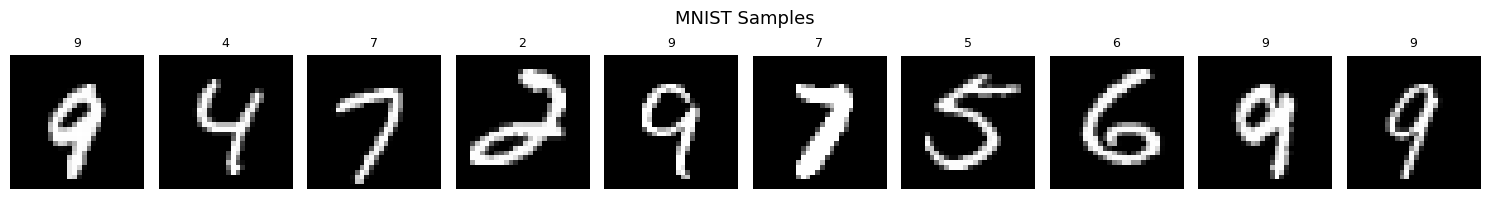

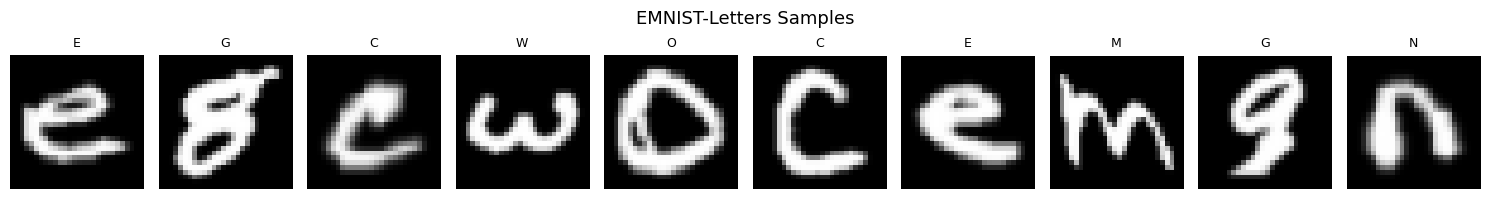


Image shape : torch.Size([1, 28, 28])
As sequence : (batch, 28, 28)  ← squeeze channel dim in model


In [2]:
BATCH_SIZE = 128
EPOCHS = 5
INPUT_SIZE = 28
SEQ_LEN = 28
MNIST_CLASSES = 10
EMNIST_CLASSES = 26

# MNIST
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = torchvision.datasets.MNIST(
    root='/kaggle/working/data', train=True,
    download=True, transform=mnist_transform
)
mnist_test = torchvision.datasets.MNIST(
    root='/kaggle/working/data', train=False,
    download=True, transform=mnist_transform
)

mnist_train_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
mnist_test_loader  = DataLoader(mnist_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"MNIST     → Train: {len(mnist_train):>6} | Test: {len(mnist_test):>5}")

# EMNIST-Letters
# EMNIST images are rotated 90° by default → rotate + flip
emnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.rot90(x, k=1, dims=[1, 2])),   # rotate 90°
    transforms.Lambda(lambda x: torch.flip(x, dims=[1])),            # vertical flip
    transforms.Normalize((0.1722,), (0.3309,))
])

emnist_train = torchvision.datasets.EMNIST(
    root='/kaggle/working/data', split='letters', train=True,
    download=True, transform=emnist_transform
)
emnist_test = torchvision.datasets.EMNIST(
    root='/kaggle/working/data', split='letters', train=False,
    download=True, transform=emnist_transform
)

# EMNIST-Letters labels are 1–26, remap to 0–25
emnist_train.targets -= 1
emnist_test.targets  -= 1

emnist_train_loader = DataLoader(emnist_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
emnist_test_loader  = DataLoader(emnist_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"EMNIST-L  → Train: {len(emnist_train):>6} | Test: {len(emnist_test):>5}")

# Visualize Samples
def plot_samples(dataset, title, label_map=None, n=10):
    fig, axes = plt.subplots(1, n, figsize=(15, 2))
    fig.suptitle(title, fontsize=13)
    indices = random.sample(range(len(dataset)), n)
    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        ax.imshow(img.squeeze(), cmap='gray')
        lbl = label_map[label] if label_map else str(label)
        ax.set_title(lbl, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

mnist_labels  = {i: str(i) for i in range(10)}
emnist_labels = {i: chr(65 + i) for i in range(26)}   # 0→A, 1→B, ...

plot_samples(mnist_train,  "MNIST Samples",         label_map=mnist_labels)
plot_samples(emnist_train, "EMNIST-Letters Samples", label_map=emnist_labels)

sample_img, sample_lbl = mnist_train[0]
print(f"\nImage shape : {sample_img.shape}")   # (1, 28, 28)
print(f"As sequence : (batch, {SEQ_LEN}, {INPUT_SIZE})  ← squeeze channel dim in model")

## 1) Vanilla RNN

In [3]:
# RNN From Scratch
class VanillaRNNScratch(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_xh = nn.Linear(input_size, hidden_size, bias=False)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=True)
        self.W_out = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.squeeze(1)           # (B, 1, 28, 28) → (B, 28, 28)
        B = x.size(0)
        h = torch.zeros(B, self.hidden_size).to(x.device)
        for t in range(x.size(1)):
            x_t = x[:, t, :]
            h = torch.tanh(self.W_xh(x_t) + self.W_hh(h))
        return self.W_out(h)


# RNN Using PyTorch (nn.RNN)
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh'
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (B, 1, 28, 28) → (B, 28, 28)
        x = x.squeeze(1)
        out, _ = self.rnn(x)       # out: (B, 28, hidden_size)
        out = self.fc(out[:, -1, :])  # last timestep
        return out

In [4]:
# Reusable Training Loop
def train_model(model, train_loader, test_loader, optimizer, criterion, epochs, model_name="Model"):
    model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        # Validate
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss    += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / len(test_loader)
        val_acc  = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    return history

In [5]:
# Vanishing Gradient Analysis
def analyze_gradients(model, loader, criterion):
    model.to(device)
    model.train()
    imgs, labels = next(iter(loader))
    imgs, labels = imgs.to(device), labels.to(device)

    # Forward pass with hooks to capture per-timestep gradients
    x = imgs.squeeze(1)          # (B, 28, 28)
    B = x.size(0)
    h = torch.zeros(B, model.hidden_size, requires_grad=True).to(device)

    grad_mags = []
    hs = []
    for t in range(x.size(1)):
        x_t = x[:, t, :]
        h = torch.tanh(model.W_xh(x_t) + model.W_hh(h))
        hs.append(h)

    out = model.W_out(hs[-1])
    loss = criterion(out, labels)
    loss.backward()

    # Gradient magnitude at each timestep via autograd
    for t, h_t in enumerate(hs):
        if h_t.grad is not None:
            grad_mags.append(h_t.grad.abs().mean().item())
        else:
            # Recompute grad manually
            grad_mags.append(0.0)

    return grad_mags

In [6]:
# Row-wise vs Column-wise
def get_columnwise_loader(dataset, batch_size):
    # Transpose (1,28,28) → will be handled in model forward
    # We flag this via a wrapper
    class ColWiseDataset(torch.utils.data.Dataset):
        def __init__(self, ds): self.ds = ds
        def __len__(self): return len(self.ds)
        def __getitem__(self, idx):
            img, label = self.ds[idx]
            return img.permute(0, 2, 1), label   # transpose H and W

    return DataLoader(ColWiseDataset(dataset), batch_size=batch_size,
                      shuffle=False, num_workers=2)

In [7]:
criterion = nn.CrossEntropyLoss()

# From-Scratch RNN (MNIST only, 1 config)
print("=" * 60)
print("RNN FROM SCRATCH — MNIST")
print("=" * 60)
scratch_rnn = VanillaRNNScratch(INPUT_SIZE, hidden_size=128, num_classes=MNIST_CLASSES)
opt_scratch  = optim.Adam(scratch_rnn.parameters(), lr=0.001)
scratch_hist = train_model(scratch_rnn, mnist_train_loader, mnist_test_loader,
                            opt_scratch, criterion, EPOCHS, "RNN-Scratch")

# PyTorch RNN — Grid over layers × hidden units
configs = [
    (1, 64), (1, 128), (1, 256),
    (2, 64), (2, 128), (2, 256),
    (3, 64), (3, 128), (3, 256),
]

rnn_results = {}   # key: (dataset, layers, hidden) → history

for dataset_name, train_loader, test_loader, num_classes in [
    ('MNIST',   mnist_train_loader,  mnist_test_loader,  MNIST_CLASSES),
    ('EMNIST',  emnist_train_loader, emnist_test_loader, EMNIST_CLASSES),
]:
    for (num_layers, hidden_size) in configs:
        key = (dataset_name, num_layers, hidden_size)
        print(f"\n{'='*60}")
        print(f"PyTorch RNN | {dataset_name} | Layers={num_layers} | Hidden={hidden_size}")
        print("=" * 60)
        model = VanillaRNN(INPUT_SIZE, hidden_size, num_layers, num_classes)
        opt   = optim.Adam(model.parameters(), lr=0.001)
        hist  = train_model(model, train_loader, test_loader,
                             opt, criterion, EPOCHS,
                             f"RNN-{dataset_name}-L{num_layers}-H{hidden_size}")
        rnn_results[key] = hist

RNN FROM SCRATCH — MNIST
[RNN-Scratch] Epoch 1/5 | Train Loss: 0.8940 Acc: 0.6907 | Val Loss: 0.5633 Acc: 0.7963
[RNN-Scratch] Epoch 2/5 | Train Loss: 0.3967 Acc: 0.8835 | Val Loss: 0.2670 Acc: 0.9275
[RNN-Scratch] Epoch 3/5 | Train Loss: 0.2522 Acc: 0.9304 | Val Loss: 0.2305 Acc: 0.9351
[RNN-Scratch] Epoch 4/5 | Train Loss: 0.1938 Acc: 0.9464 | Val Loss: 0.1940 Acc: 0.9453
[RNN-Scratch] Epoch 5/5 | Train Loss: 0.1688 Acc: 0.9535 | Val Loss: 0.1647 Acc: 0.9537

PyTorch RNN | MNIST | Layers=1 | Hidden=64
[RNN-MNIST-L1-H64] Epoch 1/5 | Train Loss: 1.1781 Acc: 0.5868 | Val Loss: 0.7023 Acc: 0.7608
[RNN-MNIST-L1-H64] Epoch 2/5 | Train Loss: 0.6079 Acc: 0.7918 | Val Loss: 0.5056 Acc: 0.8221
[RNN-MNIST-L1-H64] Epoch 3/5 | Train Loss: 0.4677 Acc: 0.8501 | Val Loss: 0.3903 Acc: 0.8846
[RNN-MNIST-L1-H64] Epoch 4/5 | Train Loss: 0.3759 Acc: 0.8898 | Val Loss: 0.3210 Acc: 0.9068
[RNN-MNIST-L1-H64] Epoch 5/5 | Train Loss: 0.3113 Acc: 0.9115 | Val Loss: 0.3058 Acc: 0.9105

PyTorch RNN | MNIST | Lay


VANISHING GRADIENT ANALYSIS


/tmp/ipykernel_24/287770815.py:26: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  if h_t.grad is not None:


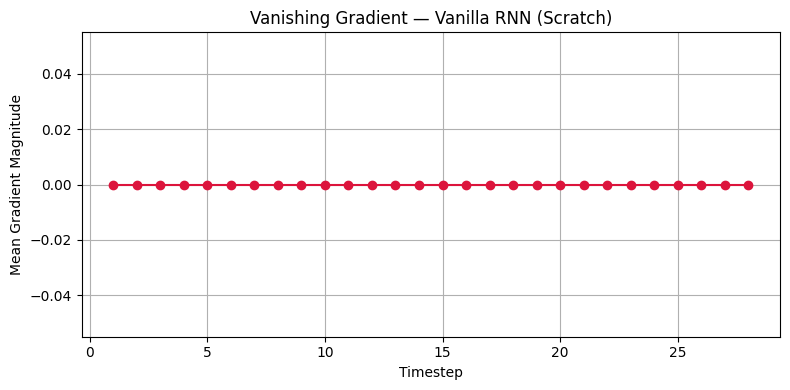

In [8]:
# Vanishing Gradient (best scratch model)
print("\n" + "=" * 60)
print("VANISHING GRADIENT ANALYSIS")
print("=" * 60)
grad_mags = analyze_gradients(scratch_rnn, mnist_train_loader, criterion)
plt.figure(figsize=(8, 4))
plt.plot(range(1, 29), grad_mags, marker='o', color='crimson')
plt.xlabel("Timestep")
plt.ylabel("Mean Gradient Magnitude")
plt.title("Vanishing Gradient — Vanilla RNN (Scratch)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# Row-wise vs Column-wise
print("\n" + "=" * 60)
print("ROW-WISE vs COLUMN-WISE — MNIST")
print("=" * 60)
col_loader = get_columnwise_loader(mnist_test, BATCH_SIZE)

model_row = VanillaRNN(INPUT_SIZE, 128, 1, MNIST_CLASSES)
model_col = VanillaRNN(INPUT_SIZE, 128, 1, MNIST_CLASSES)

hist_row = train_model(model_row, mnist_train_loader, mnist_test_loader,
                        optim.Adam(model_row.parameters(), lr=0.001),
                        criterion, EPOCHS, "RNN-RowWise")

col_train_loader = get_columnwise_loader(mnist_train, BATCH_SIZE)
hist_col = train_model(model_col, col_train_loader, col_loader,
                        optim.Adam(model_col.parameters(), lr=0.001),
                        criterion, EPOCHS, "RNN-ColWise")


ROW-WISE vs COLUMN-WISE — MNIST
[RNN-RowWise] Epoch 1/5 | Train Loss: 0.7948 Acc: 0.7384 | Val Loss: 0.3931 Acc: 0.8857
[RNN-RowWise] Epoch 2/5 | Train Loss: 0.3140 Acc: 0.9106 | Val Loss: 0.2519 Acc: 0.9282
[RNN-RowWise] Epoch 3/5 | Train Loss: 0.2350 Acc: 0.9338 | Val Loss: 0.2007 Acc: 0.9443
[RNN-RowWise] Epoch 4/5 | Train Loss: 0.1828 Acc: 0.9496 | Val Loss: 0.1834 Acc: 0.9483
[RNN-RowWise] Epoch 5/5 | Train Loss: 0.1597 Acc: 0.9561 | Val Loss: 0.1451 Acc: 0.9583
[RNN-ColWise] Epoch 1/5 | Train Loss: 0.9675 Acc: 0.6864 | Val Loss: 0.6846 Acc: 0.7768
[RNN-ColWise] Epoch 2/5 | Train Loss: 0.4038 Acc: 0.8868 | Val Loss: 0.3361 Acc: 0.9003
[RNN-ColWise] Epoch 3/5 | Train Loss: 0.2934 Acc: 0.9185 | Val Loss: 0.2350 Acc: 0.9334
[RNN-ColWise] Epoch 4/5 | Train Loss: 0.2378 Acc: 0.9339 | Val Loss: 0.2191 Acc: 0.9392
[RNN-ColWise] Epoch 5/5 | Train Loss: 0.1984 Acc: 0.9448 | Val Loss: 0.2062 Acc: 0.9459


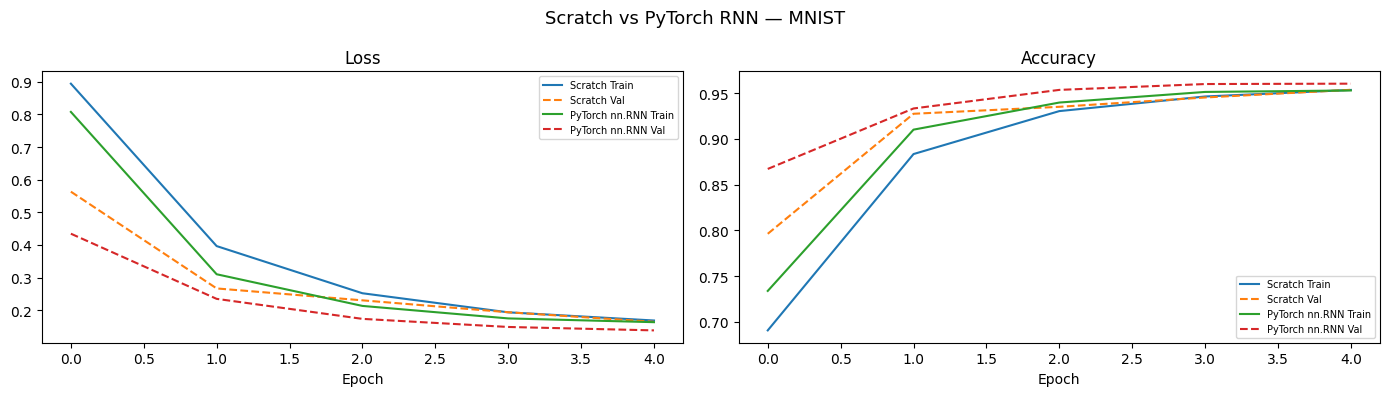

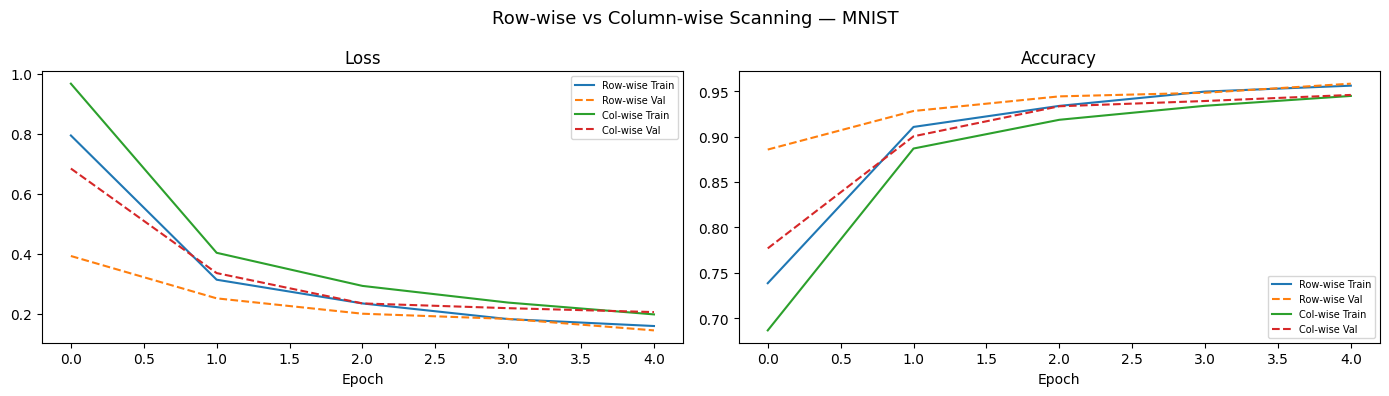

In [10]:
# Plots
def plot_history(histories, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=13)
    for hist, label in zip(histories, labels):
        axes[0].plot(hist['train_loss'], label=f'{label} Train')
        axes[0].plot(hist['val_loss'],   label=f'{label} Val', linestyle='--')
        axes[1].plot(hist['train_acc'],  label=f'{label} Train')
        axes[1].plot(hist['val_acc'],    label=f'{label} Val', linestyle='--')
    axes[0].set_title("Loss");   axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=7)
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=7)
    plt.tight_layout(); plt.show()

# Scratch vs best PyTorch RNN
best_pytorch_hist = rnn_results[('MNIST', 1, 128)]
plot_history([scratch_hist, best_pytorch_hist],
             ["Scratch", "PyTorch nn.RNN"],
             "Scratch vs PyTorch RNN — MNIST")

# Row vs Col
plot_history([hist_row, hist_col],
             ["Row-wise", "Col-wise"],
             "Row-wise vs Column-wise Scanning — MNIST")

In [11]:
# Summary table
print("\n── RNN Results Summary ──────────────────────────────────")
print(f"{'Dataset':<10} {'Layers':<8} {'Hidden':<8} {'Val Acc':>8}")
print("-" * 38)
for (ds, nl, hs), hist in rnn_results.items():
    best_acc = max(hist['val_acc'])
    print(f"{ds:<10} {nl:<8} {hs:<8} {best_acc:>8.4f}")


── RNN Results Summary ──────────────────────────────────
Dataset    Layers   Hidden    Val Acc
--------------------------------------
MNIST      1        64         0.9105
MNIST      1        128        0.9604
MNIST      1        256        0.9638
MNIST      2        64         0.9556
MNIST      2        128        0.9657
MNIST      2        256        0.9731
MNIST      3        64         0.9657
MNIST      3        128        0.9737
MNIST      3        256        0.9745
EMNIST     1        64         0.7626
EMNIST     1        128        0.8475
EMNIST     1        256        0.8673
EMNIST     2        64         0.8275
EMNIST     2        128        0.8737
EMNIST     2        256        0.8788
EMNIST     3        64         0.8552
EMNIST     3        128        0.8904
EMNIST     3        256        0.8825


## 2) LSTM

In [12]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

In [13]:
def visualize_gate_activations(model, loader, dataset_name):
    model.to(device)
    model.eval()

    imgs, labels = next(iter(loader))
    imgs = imgs.to(device)
    x = imgs[:1].squeeze(1)        # single sample: (1, 28, 28)

    gate_f, gate_i, gate_o, cell_c = [], [], [], []

    with torch.no_grad():
        h = torch.zeros(1, 1, model.lstm.hidden_size).to(device)
        c = torch.zeros(1, 1, model.lstm.hidden_size).to(device)

        for t in range(x.size(1)):
            x_t = x[:, t:t+1, :]          # (1, 1, input_size)
            out, (h, c) = model.lstm(x_t, (h, c))

            H = model.lstm.hidden_size
            w_ih = model.lstm.weight_ih_l0  # (4H, input_size)
            w_hh = model.lstm.weight_hh_l0  # (4H, H)
            b_ih = model.lstm.bias_ih_l0
            b_hh = model.lstm.bias_hh_l0

            # x_t: (1, input_size), h: (1, H)
            gates = (x_t.squeeze(1) @ w_ih.T + b_ih +
                     h.squeeze(0) @ w_hh.T + b_hh)  # (1, 4H)

            i_g = torch.sigmoid(gates[:, 0*H : 1*H])
            f_g = torch.sigmoid(gates[:, 1*H : 2*H])
            o_g = torch.sigmoid(gates[:, 3*H : 4*H])

            gate_i.append(i_g.mean().item())
            gate_f.append(f_g.mean().item())
            gate_o.append(o_g.mean().item())
            cell_c.append(c.mean().item())

    plt.figure(figsize=(10, 4))
    plt.plot(gate_f, label='Forget Gate',      color='red')
    plt.plot(gate_i, label='Input Gate',       color='blue')
    plt.plot(gate_o, label='Output Gate',      color='green')
    plt.plot(cell_c, label='Cell State (mean)', color='orange', linestyle='--')
    plt.xlabel("Timestep")
    plt.ylabel("Mean Activation")
    plt.title(f"LSTM Gate Activations — {dataset_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [14]:
# Run
lstm_results = {}

lstm_configs = [
    (1,32,0.0), (1,64,0.0), (1,128,0.0), (1,256,0.0),
    (2,128,0.0), (2,128,0.2), (2,128,0.3), (2,128, 0.5)
]

for dataset_name, train_loader, test_loader, num_classes in [
    ('MNIST', mnist_train_loader, mnist_test_loader, MNIST_CLASSES),
    ('EMNIST', emnist_train_loader, emnist_test_loader, EMNIST_CLASSES),
]:
    for (num_layers, hidden_size, dropout) in lstm_configs:
        key = (dataset_name, num_layers, hidden_size, dropout)
        print(f"\n{'='*60}")
        print(f"LSTM | {dataset_name} | Layers={num_layers} | Hidden={hidden_size} | Dropout={dropout}")
        print("=" * 60)
        model = LSTMModel(INPUT_SIZE, hidden_size, num_layers, num_classes, dropout)
        opt = optim.Adam(model.parameters(), lr=0.001)
        hist = train_model(model, train_loader, test_loader,
                           opt, criterion, EPOCHS,
                           f"LSTM-{dataset_name}-L{num_layers}-H{hidden_size}-D{dropout}")
        lstm_results[key] = hist


LSTM | MNIST | Layers=1 | Hidden=32 | Dropout=0.0
[LSTM-MNIST-L1-H32-D0.0] Epoch 1/5 | Train Loss: 0.9542 Acc: 0.6966 | Val Loss: 0.3510 Acc: 0.9055
[LSTM-MNIST-L1-H32-D0.0] Epoch 2/5 | Train Loss: 0.2892 Acc: 0.9183 | Val Loss: 0.2198 Acc: 0.9375
[LSTM-MNIST-L1-H32-D0.0] Epoch 3/5 | Train Loss: 0.2004 Acc: 0.9424 | Val Loss: 0.1698 Acc: 0.9485
[LSTM-MNIST-L1-H32-D0.0] Epoch 4/5 | Train Loss: 0.1648 Acc: 0.9522 | Val Loss: 0.1475 Acc: 0.9570
[LSTM-MNIST-L1-H32-D0.0] Epoch 5/5 | Train Loss: 0.1383 Acc: 0.9597 | Val Loss: 0.1374 Acc: 0.9577

LSTM | MNIST | Layers=1 | Hidden=64 | Dropout=0.0
[LSTM-MNIST-L1-H64-D0.0] Epoch 1/5 | Train Loss: 0.7127 Acc: 0.7702 | Val Loss: 0.1940 Acc: 0.9470
[LSTM-MNIST-L1-H64-D0.0] Epoch 2/5 | Train Loss: 0.1650 Acc: 0.9530 | Val Loss: 0.1162 Acc: 0.9656
[LSTM-MNIST-L1-H64-D0.0] Epoch 3/5 | Train Loss: 0.1126 Acc: 0.9682 | Val Loss: 0.0905 Acc: 0.9739
[LSTM-MNIST-L1-H64-D0.0] Epoch 4/5 | Train Loss: 0.0889 Acc: 0.9739 | Val Loss: 0.0865 Acc: 0.9743
[LSTM-M


Gate Activation Visualization
[LSTM-Gate-MNIST] Epoch 1/5 | Train Loss: 0.4958 Acc: 0.8408 | Val Loss: 0.1251 Acc: 0.9627
[LSTM-Gate-MNIST] Epoch 2/5 | Train Loss: 0.1073 Acc: 0.9679 | Val Loss: 0.0808 Acc: 0.9752
[LSTM-Gate-MNIST] Epoch 3/5 | Train Loss: 0.0720 Acc: 0.9784 | Val Loss: 0.0760 Acc: 0.9748
[LSTM-Gate-MNIST] Epoch 4/5 | Train Loss: 0.0559 Acc: 0.9833 | Val Loss: 0.0554 Acc: 0.9833
[LSTM-Gate-MNIST] Epoch 5/5 | Train Loss: 0.0455 Acc: 0.9867 | Val Loss: 0.0537 Acc: 0.9831


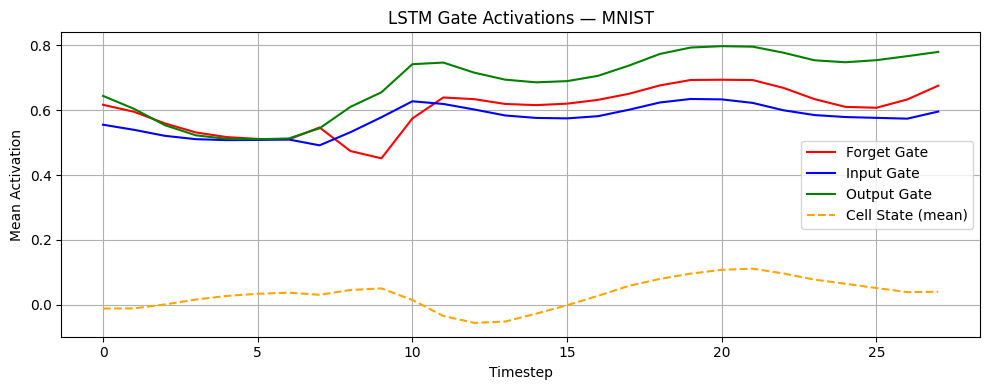

[LSTM-Gate-EMNIST] Epoch 1/5 | Train Loss: 0.8632 Acc: 0.7400 | Val Loss: 0.3892 Acc: 0.8821
[LSTM-Gate-EMNIST] Epoch 2/5 | Train Loss: 0.3331 Acc: 0.8941 | Val Loss: 0.3064 Acc: 0.9025
[LSTM-Gate-EMNIST] Epoch 3/5 | Train Loss: 0.2682 Acc: 0.9123 | Val Loss: 0.2764 Acc: 0.9101
[LSTM-Gate-EMNIST] Epoch 4/5 | Train Loss: 0.2345 Acc: 0.9214 | Val Loss: 0.2562 Acc: 0.9164
[LSTM-Gate-EMNIST] Epoch 5/5 | Train Loss: 0.2120 Acc: 0.9278 | Val Loss: 0.2515 Acc: 0.9173


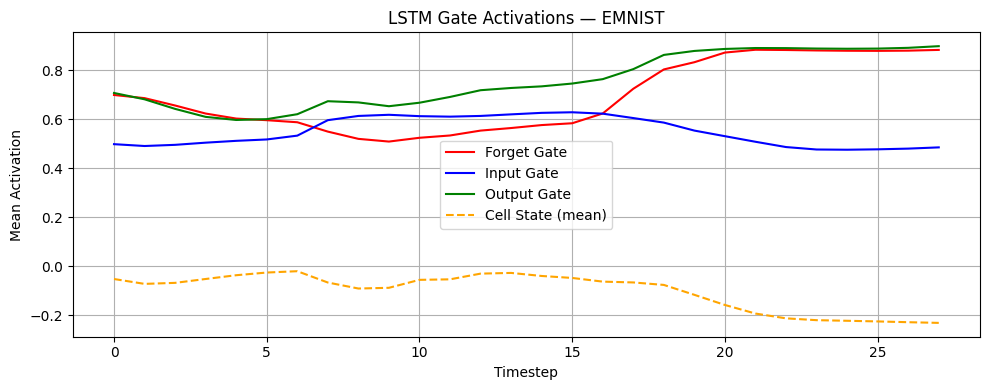

In [15]:
# Gate Visualization
print("\n" + "=" * 60)
print("Gate Activation Visualization")
print("=" * 60)

for dataset_name, train_loader, test_loader, num_classes in [
    ('MNIST', mnist_train_loader, mnist_test_loader, MNIST_CLASSES),
    ('EMNIST', emnist_train_loader, emnist_test_loader, EMNIST_CLASSES),
]:
    gate_model = LSTMModel(INPUT_SIZE, 128, 1, num_classes, dropout=0.0)
    opt_gate = optim.Adam(gate_model.parameters(), lr=0.001)
    train_model(gate_model, train_loader, test_loader,
                opt_gate, criterion, EPOCHS,
                f"LSTM-Gate-{dataset_name}")
    visualize_gate_activations(gate_model, test_loader, dataset_name)


Dropout Analysis -MNIST, L=2, H=128


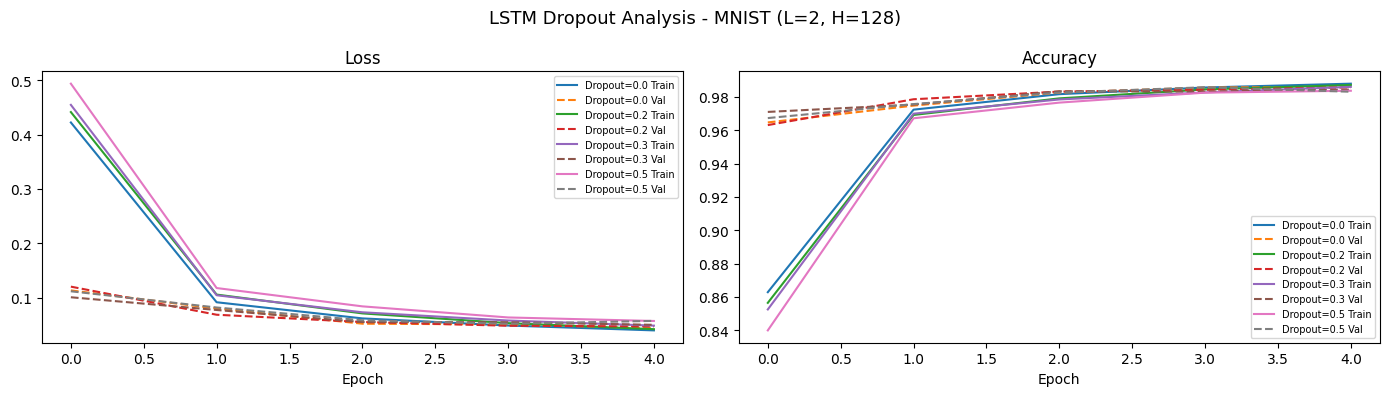

In [16]:
# Dropout Analysis Plot
print("\n" + "=" * 60)
print("Dropout Analysis -MNIST, L=2, H=128")
print("=" * 60)

dropout_vals = [0.0, 0.2, 0.3, 0.5]
dropout_hists = [lstm_results[('MNIST', 2, 128, d)] for d in dropout_vals]
dropout_labels = [f"Dropout={d}" for d in dropout_vals]
plot_history(dropout_hists, dropout_labels, "LSTM Dropout Analysis - MNIST (L=2, H=128)")


LSTM vs Vanilla RNN - MNIST & EMNIST (L=1, H=128)


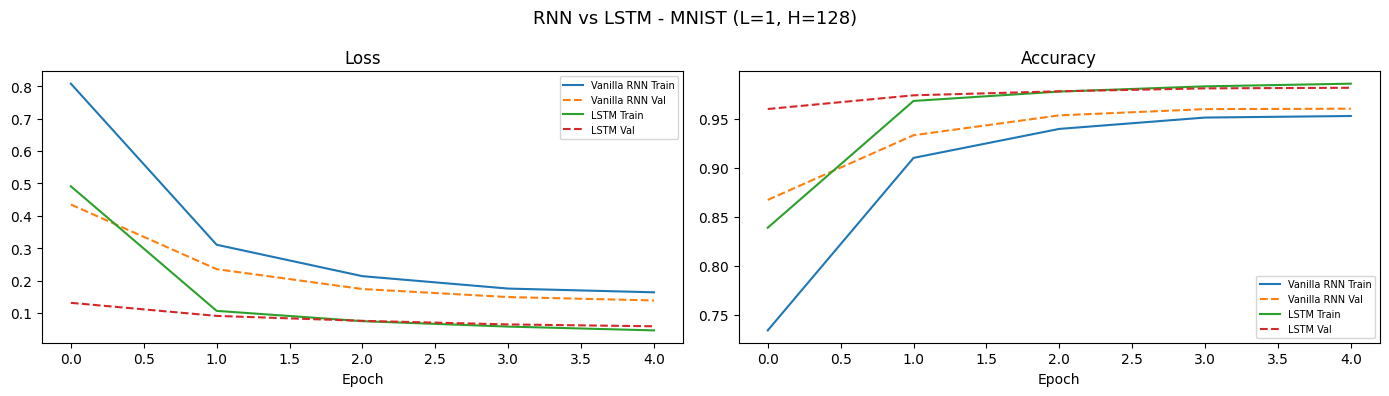

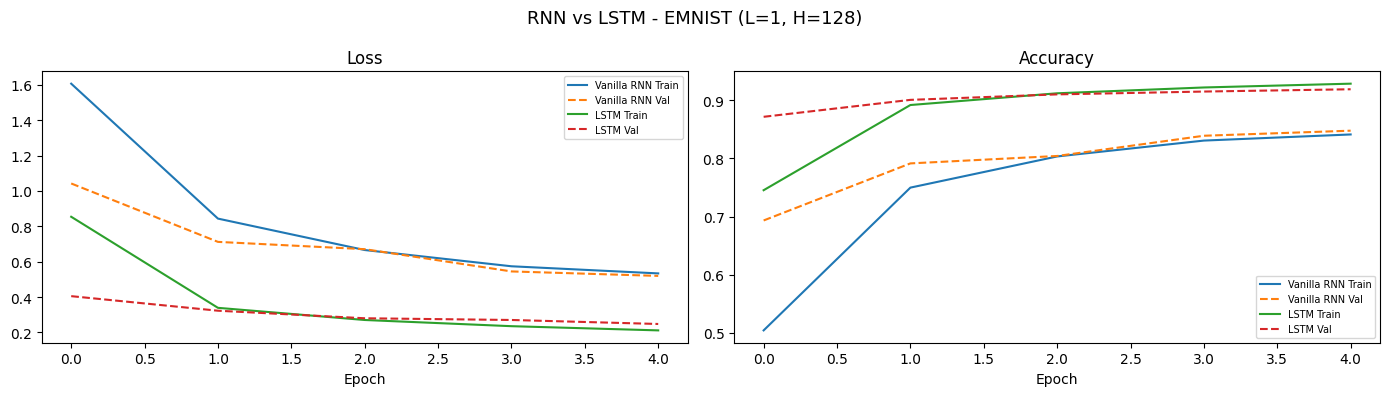

In [17]:
# LSTM vs Vanilla RNN Comparison
print("\n" + "=" * 60)
print("LSTM vs Vanilla RNN - MNIST & EMNIST (L=1, H=128)")
print("=" * 60)

for dataset_name in ['MNIST', 'EMNIST']:
    rnn_hist = rnn_results[(dataset_name, 1, 128)]
    lstm_hist = lstm_results[(dataset_name, 1, 128, 0.0)]
    plot_history([rnn_hist, lstm_hist],
                 ["Vanilla RNN", "LSTM"],
                 f"RNN vs LSTM - {dataset_name} (L=1, H=128)")

In [18]:
# Summary Table
print("\n── LSTM Results Summary ─────────────────────────────────")
print(f"{'Dataset':<10} {'Layers':<8} {'Hidden':<8} {'Dropout':<10} {'Val Acc':>8}")
print("-" * 48)
for (ds, nl, hs, dr), hist in lstm_results.items():
    best_acc = max(hist['val_acc'])
    print(f"{ds:<10} {nl:<8} {hs:<8} {dr:<10} {best_acc:>8.4f}")


── LSTM Results Summary ─────────────────────────────────
Dataset    Layers   Hidden   Dropout     Val Acc
------------------------------------------------
MNIST      1        32       0.0          0.9577
MNIST      1        64       0.0          0.9765
MNIST      1        128      0.0          0.9818
MNIST      1        256      0.0          0.9861
MNIST      2        128      0.0          0.9861
MNIST      2        128      0.2          0.9857
MNIST      2        128      0.3          0.9844
MNIST      2        128      0.5          0.9858
EMNIST     1        32       0.0          0.8560
EMNIST     1        64       0.0          0.8999
EMNIST     1        128      0.0          0.9187
EMNIST     1        256      0.0          0.9281
EMNIST     2        128      0.0          0.9295
EMNIST     2        128      0.2          0.9297
EMNIST     2        128      0.3          0.9271
EMNIST     2        128      0.5          0.9287


## 3) GRU

In [19]:
# GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)
    
# Parameter Count Helper
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [20]:
# Run
# Stacked layers: [1, 2, 3], fixed hidden=128, dropout=0.0
gru_configs = [
    (1, 128, 0.0),
    (2, 128, 0.0),
    (3, 128, 0.0),
]

gru_results = {}

for dataset_name, train_loader, test_loader, num_classes in [
    ('MNIST', mnist_train_loader, mnist_test_loader, MNIST_CLASSES),
    ('EMNIST', emnist_train_loader, emnist_test_loader, EMNIST_CLASSES),
]:
    for (num_layers, hidden_size, dropout) in gru_configs:
        key = (dataset_name, num_layers, hidden_size, dropout)
        print(f"\n{'='*60}")
        print(f"GRU | {dataset_name} | Layers={num_layers} | Hidden={hidden_size}")
        print("=" * 60)
        model = GRUModel(INPUT_SIZE, hidden_size, num_layers, num_classes, dropout)
        opt = optim.Adam(model.parameters(), lr=0.001)
        hist = train_model(model, train_loader, test_loader,
                           opt, criterion, EPOCHS,
                           f"GRU-{dataset_name}-L{num_layers}-H{hidden_size}")
        gru_results[key] = hist


GRU | MNIST | Layers=1 | Hidden=128
[GRU-MNIST-L1-H128] Epoch 1/5 | Train Loss: 0.5258 Acc: 0.8288 | Val Loss: 0.1229 Acc: 0.9644
[GRU-MNIST-L1-H128] Epoch 2/5 | Train Loss: 0.1087 Acc: 0.9679 | Val Loss: 0.0875 Acc: 0.9725
[GRU-MNIST-L1-H128] Epoch 3/5 | Train Loss: 0.0718 Acc: 0.9789 | Val Loss: 0.0629 Acc: 0.9800
[GRU-MNIST-L1-H128] Epoch 4/5 | Train Loss: 0.0545 Acc: 0.9837 | Val Loss: 0.0577 Acc: 0.9816
[GRU-MNIST-L1-H128] Epoch 5/5 | Train Loss: 0.0442 Acc: 0.9867 | Val Loss: 0.0453 Acc: 0.9856

GRU | MNIST | Layers=2 | Hidden=128
[GRU-MNIST-L2-H128] Epoch 1/5 | Train Loss: 0.4281 Acc: 0.8584 | Val Loss: 0.0990 Acc: 0.9703
[GRU-MNIST-L2-H128] Epoch 2/5 | Train Loss: 0.0874 Acc: 0.9737 | Val Loss: 0.0544 Acc: 0.9836
[GRU-MNIST-L2-H128] Epoch 3/5 | Train Loss: 0.0544 Acc: 0.9834 | Val Loss: 0.0449 Acc: 0.9860
[GRU-MNIST-L2-H128] Epoch 4/5 | Train Loss: 0.0425 Acc: 0.9869 | Val Loss: 0.0405 Acc: 0.9884
[GRU-MNIST-L2-H128] Epoch 5/5 | Train Loss: 0.0308 Acc: 0.9906 | Val Loss: 0.047

In [21]:
# GRU vs LSTM
print("\n" + "=" * 60)
print("4.2 GRU vs LSTM COMPARISON — L=1, H=128")
print("=" * 60)

# Parameter count comparison
for dataset_name, num_classes in [('MNIST', MNIST_CLASSES), ('EMNIST', EMNIST_CLASSES)]:
    lstm_m = LSTMModel(INPUT_SIZE, 128, 1, num_classes, dropout=0.0)
    gru_m  = GRUModel (INPUT_SIZE, 128, 1, num_classes, dropout=0.0)
    print(f"\n{dataset_name}")
    print(f"  LSTM params : {count_parameters(lstm_m):,}")
    print(f"  GRU  params : {count_parameters(gru_m):,}")

# Training time comparison (1 epoch, MNIST)
print("\nTraining Time (1 epoch, MNIST, H=128, L=1)")
for name, ModelClass in [('LSTM', LSTMModel), ('GRU', GRUModel)]:
    m   = ModelClass(INPUT_SIZE, 128, 1, MNIST_CLASSES, dropout=0.0).to(device)
    opt = optim.Adam(m.parameters(), lr=0.001)
    m.train()
    t0 = time.time()
    for imgs, labels in mnist_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        opt.zero_grad()
        loss = criterion(m(imgs), labels)
        loss.backward()
        opt.step()
    print(f"  {name} : {time.time() - t0:.2f}s")


4.2 GRU vs LSTM COMPARISON — L=1, H=128

MNIST
  LSTM params : 82,186
  GRU  params : 61,962

EMNIST
  LSTM params : 84,250
  GRU  params : 64,026

Training Time (1 epoch, MNIST, H=128, L=1)
  LSTM : 7.06s
  GRU : 6.90s


In [22]:
# Efficiency Analysis
print("\n" + "=" * 60)
print("4.3 EFFICIENCY ANALYSIS — FLOPs & Memory (MNIST, L=1, H=128)")
print("=" * 60)

try:
    from torchinfo import summary
    for name, ModelClass in [('LSTM', LSTMModel), ('GRU', GRUModel)]:
        m = ModelClass(INPUT_SIZE, 128, 1, MNIST_CLASSES, dropout=0.0)
        print(f"\n{name}:")
        summary(m, input_size=(1, 1, 28, 28), verbose=1)
except ImportError:
    print("torchinfo not available — skipping FLOPs summary")
    print("Install via: pip install torchinfo")

# Memory usage on GPU
if device.type == 'cuda':
    print("\n── GPU Memory ───────────────────────────────────────────")
    for name, ModelClass in [('LSTM', LSTMModel), ('GRU', GRUModel)]:
        torch.cuda.reset_peak_memory_stats()
        m = ModelClass(INPUT_SIZE, 128, 1, MNIST_CLASSES).to(device)
        imgs, _ = next(iter(mnist_train_loader))
        imgs = imgs.to(device)
        _ = m(imgs)
        mem = torch.cuda.max_memory_allocated() / 1024**2
        print(f"  {name} peak memory : {mem:.2f} MB")


4.3 EFFICIENCY ANALYSIS — FLOPs & Memory (MNIST, L=1, H=128)

LSTM:
Layer (type:depth-idx)                   Output Shape              Param #
LSTMModel                                [1, 10]                   --
├─LSTM: 1-1                              [1, 28, 128]              80,896
├─Dropout: 1-2                           [1, 128]                  --
├─Linear: 1-3                            [1, 10]                   1,290
Total params: 82,186
Trainable params: 82,186
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.27
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.33
Estimated Total Size (MB): 0.36

GRU:
Layer (type:depth-idx)                   Output Shape              Param #
GRUModel                                 [1, 10]                   --
├─GRU: 1-1                               [1, 28, 128]              60,672
├─Dropout: 1-2                           [1, 128]                  --
├─Linear: 1-3                            [1, 10] 


Stacked GRU Layers Comparison


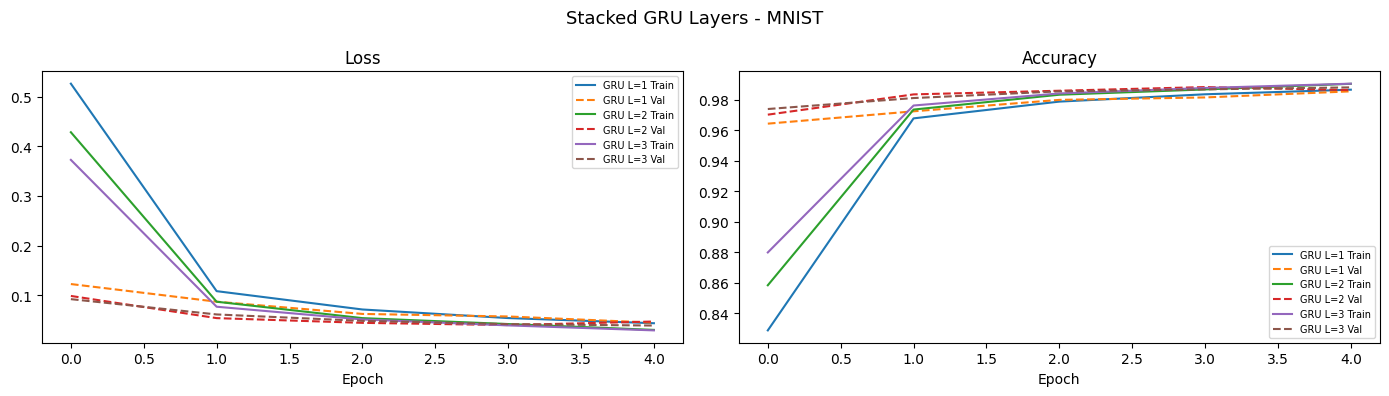

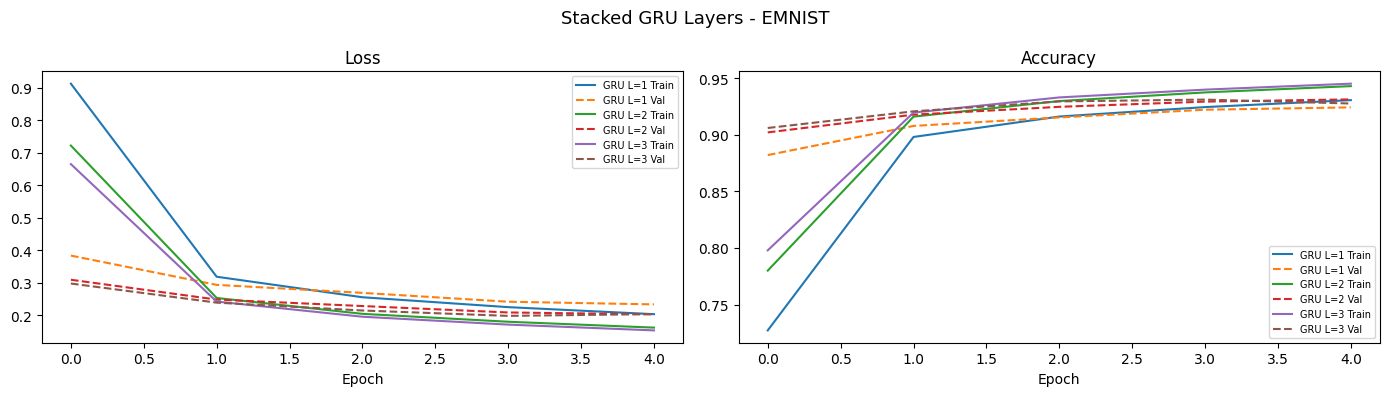

In [23]:
# Stacked GRU Layers Plot
print("\n" + "=" * 60)
print("Stacked GRU Layers Comparison")
print("=" * 60)

for dataset_name in ['MNIST', 'EMNIST']:
    hists = [gru_results[(dataset_name, nl, 128, 0.0)] for nl in [1, 2, 3]]
    labels = [f"GRU L={nl}" for nl in [1, 2, 3]]
    plot_history(hists, labels, f"Stacked GRU Layers - {dataset_name}")

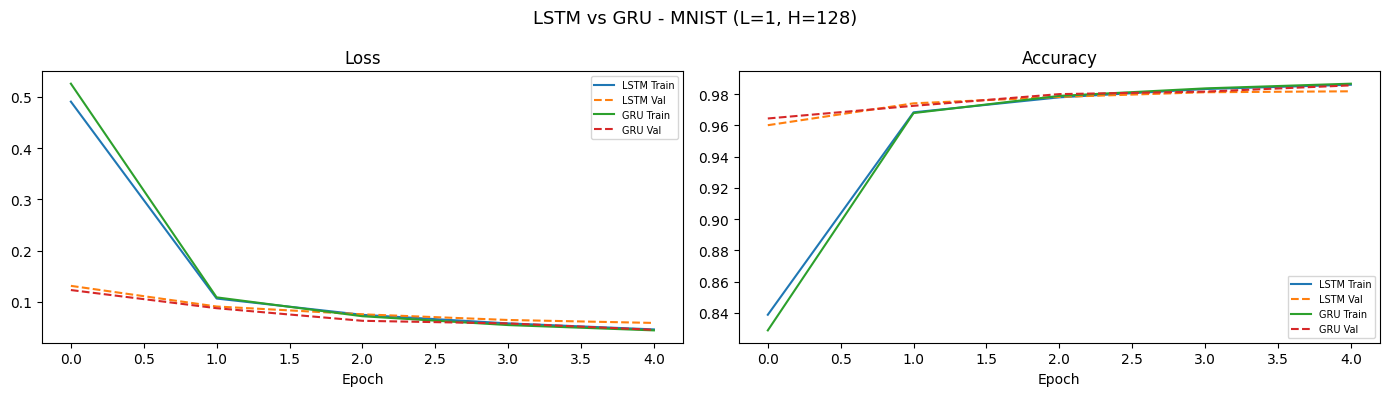

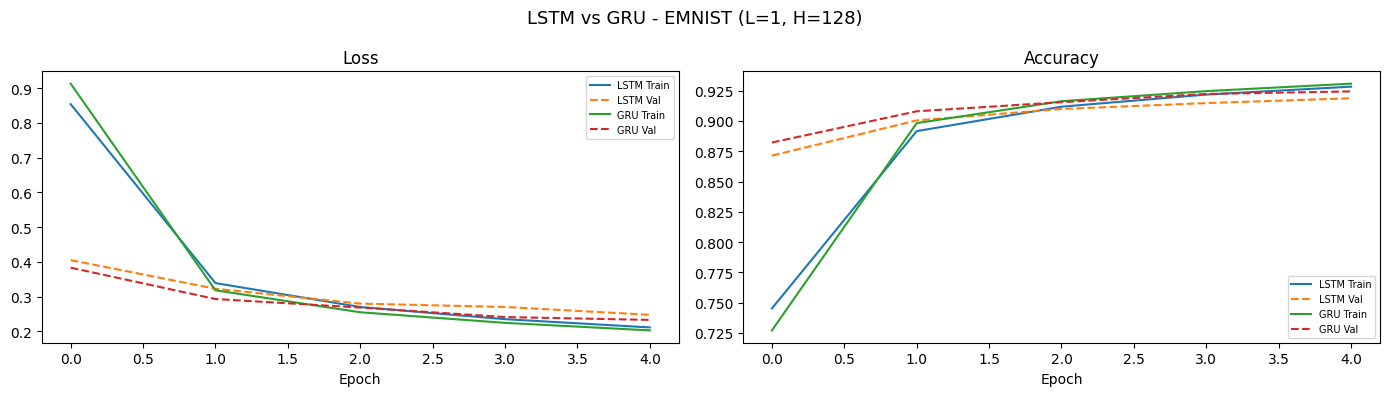

In [24]:
# GRU vs LSTM Accuracy Plot
for dataset_name in ['MNIST', 'EMNIST']:
    lstm_hist = lstm_results[(dataset_name, 1, 128, 0.0)]
    gru_hist = gru_results[(dataset_name, 1, 128, 0.0)]
    plot_history([lstm_hist, gru_hist],
                 ["LSTM", "GRU"],
                 f"LSTM vs GRU - {dataset_name} (L=1, H=128)")

In [25]:
# Summary Table
print("\n── GRU Results Summary ──────────────────────────────────")
print(f"{'Dataset':<10} {'Layers':<8} {'Hidden':<8} {'Val Acc':>8}")
print("-" * 38)
for (ds, nl, hs, dr), hist in gru_results.items():
    best_acc = max(hist['val_acc'])
    print(f"{ds:<10} {nl:<8} {hs:<8} {best_acc:>8.4f}")


── GRU Results Summary ──────────────────────────────────
Dataset    Layers   Hidden    Val Acc
--------------------------------------
MNIST      1        128        0.9856
MNIST      2        128        0.9884
MNIST      3        128        0.9882
EMNIST     1        128        0.9243
EMNIST     2        128        0.9314
EMNIST     3        128        0.9312


## 4) Bidirectional LSTM

In [26]:
class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes,
                 dropout=0.0, merge_mode='concat'):
        super().__init__()
        self.merge_mode = merge_mode
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        fc_input = hidden_size * 2 if merge_mode == 'concat' else hidden_size
        self.fc = nn.Linear(fc_input, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        out, _ = self.lstm(x)
        H = out.size(2) // 2
        fwd = out[:, -1, :H]
        bwd = out[:,  0, H:]      # fix: H: not H
        if self.merge_mode == 'concat':
            out = torch.cat([fwd, bwd], dim=1)
        else:
            out = (fwd + bwd) / 2.0
        out = self.dropout(out)
        return self.fc(out)


class BiGRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes,
                 dropout=0.0, merge_mode='concat'):
        super().__init__()
        self.merge_mode = merge_mode    # fix: was self.megre_mode
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        fc_input = hidden_size * 2 if merge_mode == 'concat' else hidden_size
        self.fc = nn.Linear(fc_input, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        out, _ = self.gru(x)
        H = out.size(2) // 2
        fwd = out[:, -1, :H]
        bwd = out[:,  0, H:]
        if self.merge_mode == 'concat':    # fix: was self.megre_mode
            out = torch.cat([fwd, bwd], dim=1)
        else:
            out = (fwd + bwd) / 2.0
        out = self.dropout(out)
        return self.fc(out)

In [27]:
# Run
# Fixed: H=128, L=1, dropout=0.0
# Vary: merge_mode (concat, avg), model type (BiLSTM, BiGRU)

bilstm_results = {}
bigru_results = {}

for dataset_name, train_loader, test_loader, num_classes in [
    ('MNIST', mnist_train_loader, mnist_test_loader, MNIST_CLASSES),
    ('EMNIST', emnist_train_loader, emnist_test_loader, EMNIST_CLASSES),
]:
    for merge_mode in ['concat', 'avg']:
        # BiLSTM
        key = (dataset_name, merge_mode)
        print(f"\n{'='*60}")
        print(f"BiLSTM | {dataset_name} | merge={merge_mode}")
        print("=" * 60)
        model = BiLSTMModel(INPUT_SIZE, 128, 1, num_classes,
                            dropout=0.0, merge_mode=merge_mode)
        opt = optim.Adam(model.parameters(), lr=0.001)
        hist = train_model(model, train_loader, test_loader,
                           opt, criterion, EPOCHS,
                           f"BiLSTM-{dataset_name}-{merge_mode}")
        bilstm_results[key] = hist

        # BiGRU
        print(f"\n{'=' * 60}")
        print(f"BiGRU | {dataset_name} | merge={merge_mode}")
        print("="*60)
        model = BiGRUModel(INPUT_SIZE, 128, 1, num_classes,
                           dropout=0.0, merge_mode=merge_mode)
        opt = optim.Adam(model.parameters(), lr=0.001)
        hist = train_model(model, train_loader, test_loader,
                           opt, criterion, EPOCHS,
                           f"BiGRU-{dataset_name}-{merge_mode}")
        bigru_results[key] = hist


BiLSTM | MNIST | merge=concat
[BiLSTM-MNIST-concat] Epoch 1/5 | Train Loss: 0.4131 Acc: 0.8662 | Val Loss: 0.1054 Acc: 0.9681
[BiLSTM-MNIST-concat] Epoch 2/5 | Train Loss: 0.0898 Acc: 0.9733 | Val Loss: 0.0686 Acc: 0.9785
[BiLSTM-MNIST-concat] Epoch 3/5 | Train Loss: 0.0608 Acc: 0.9814 | Val Loss: 0.0615 Acc: 0.9801
[BiLSTM-MNIST-concat] Epoch 4/5 | Train Loss: 0.0493 Acc: 0.9847 | Val Loss: 0.0533 Acc: 0.9822
[BiLSTM-MNIST-concat] Epoch 5/5 | Train Loss: 0.0388 Acc: 0.9878 | Val Loss: 0.0500 Acc: 0.9840

BiGRU | MNIST | merge=concat
[BiGRU-MNIST-concat] Epoch 1/5 | Train Loss: 0.4236 Acc: 0.8666 | Val Loss: 0.0944 Acc: 0.9706
[BiGRU-MNIST-concat] Epoch 2/5 | Train Loss: 0.0796 Acc: 0.9766 | Val Loss: 0.0638 Acc: 0.9800
[BiGRU-MNIST-concat] Epoch 3/5 | Train Loss: 0.0546 Acc: 0.9835 | Val Loss: 0.0438 Acc: 0.9855
[BiGRU-MNIST-concat] Epoch 4/5 | Train Loss: 0.0407 Acc: 0.9876 | Val Loss: 0.0402 Acc: 0.9880
[BiGRU-MNIST-concat] Epoch 5/5 | Train Loss: 0.0335 Acc: 0.9899 | Val Loss: 0.0


BiLSTM - Concat vs Avg Merge


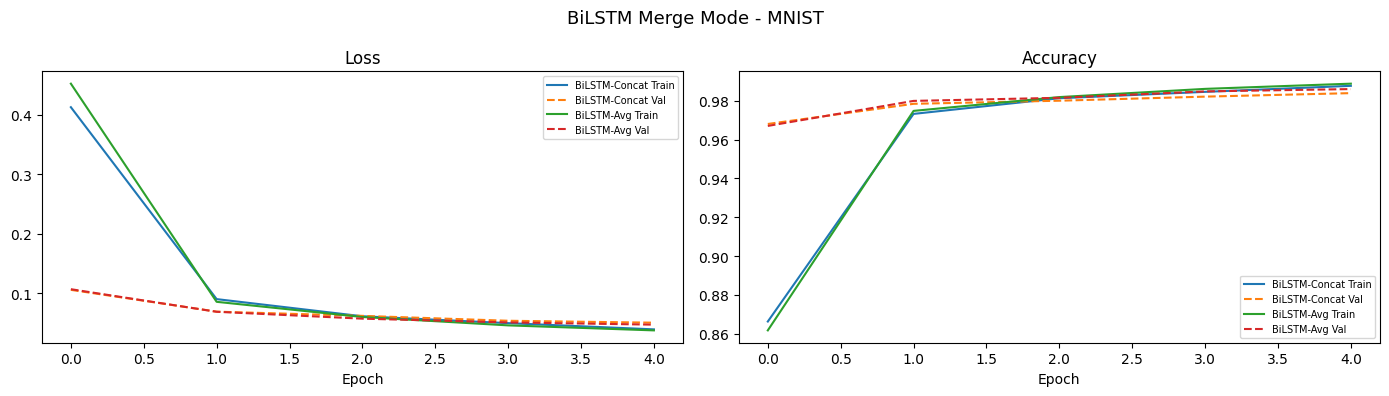

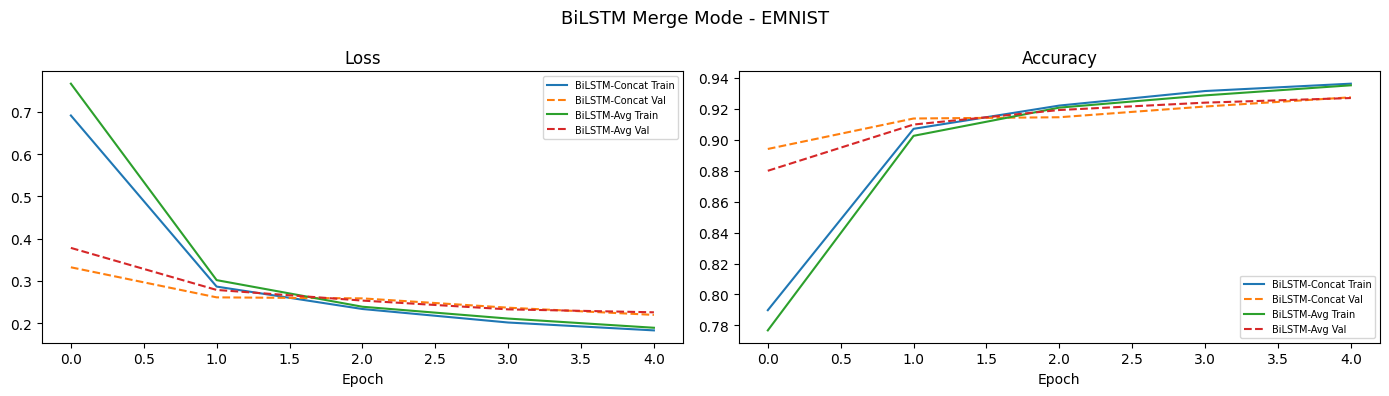

In [28]:
# BiLSTM concat vs avg
print("\n" + "=" * 60)
print("BiLSTM - Concat vs Avg Merge")
print("=" * 60)

for dataset_name in ['MNIST', 'EMNIST']:
    plot_history(
        [bilstm_results[(dataset_name, 'concat')],
         bilstm_results[(dataset_name, 'avg')]],
         ['BiLSTM-Concat','BiLSTM-Avg'],
         f"BiLSTM Merge Mode - {dataset_name}"
    )


BiLSTM vs Unidirectional LSTM - L=1, H=128


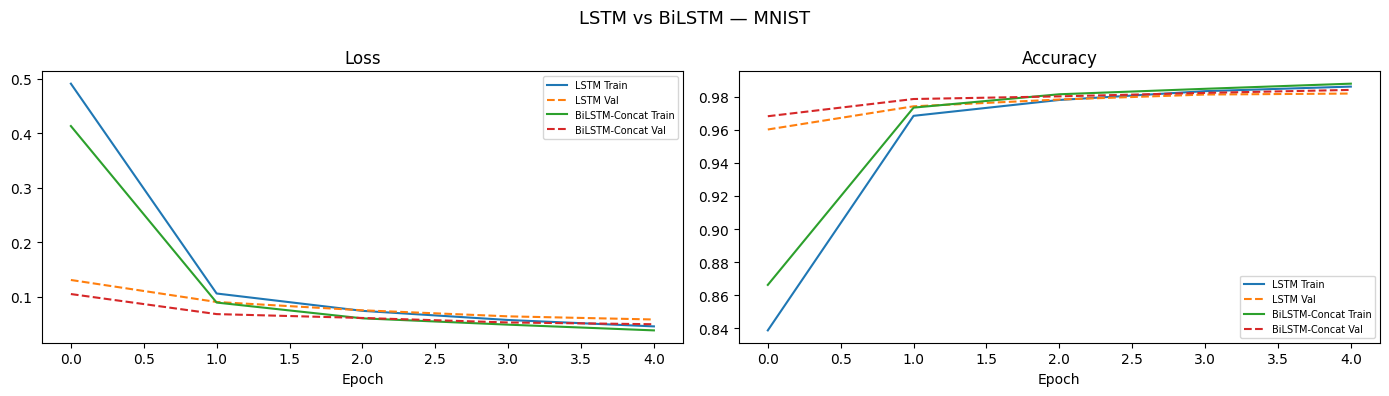

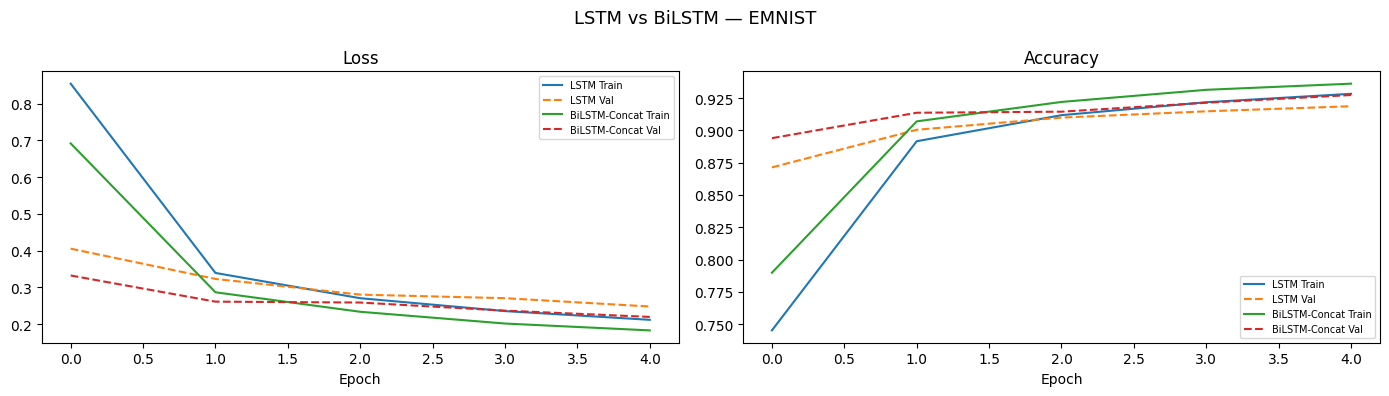

In [29]:
# BiLSTM vs Unidirectional LSTM
print("\n" + "=" * 60)
print("BiLSTM vs Unidirectional LSTM - L=1, H=128")
print("=" * 60)

for dataset_name in ['MNIST', 'EMNIST']:
    plot_history(
        [lstm_results[(dataset_name, 1, 128, 0.0)],
         bilstm_results[(dataset_name, 'concat')]],
        ["LSTM", "BiLSTM-Concat"],
        f"LSTM vs BiLSTM — {dataset_name}"
    )


BiGRU vs BiLSTM — concat, L=1, H=128


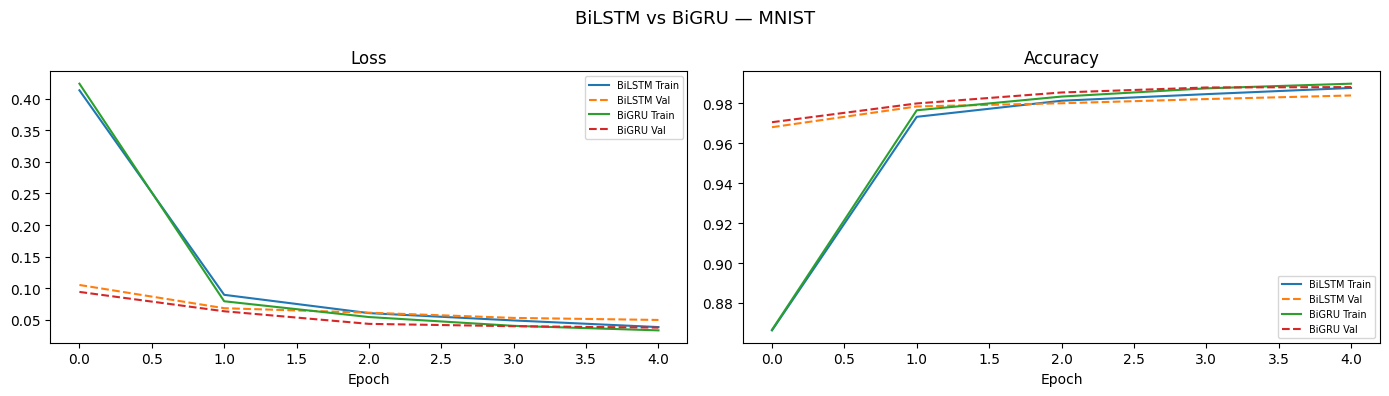

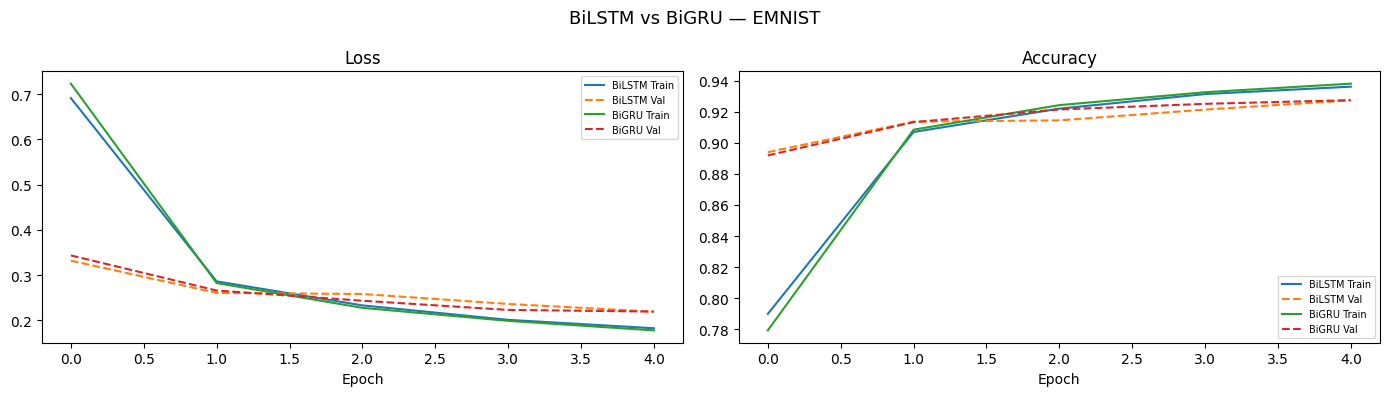

In [30]:
# ── BiGRU vs BiLSTM ───────────────────────────────────────
print("\n" + "=" * 60)
print("BiGRU vs BiLSTM — concat, L=1, H=128")
print("=" * 60)

for dataset_name in ['MNIST', 'EMNIST']:
    plot_history(
        [bilstm_results[(dataset_name, 'concat')],
         bigru_results [(dataset_name, 'concat')]],
        ["BiLSTM", "BiGRU"],
        f"BiLSTM vs BiGRU — {dataset_name}"
    )

In [31]:
# ── Does Bidirectionality Help? ──────────────────────────
print("\n" + "=" * 60)
print("ANALYSIS — Does Bidirectional Help for Image Sequences?")
print("=" * 60)

print(f"\n{'Model':<20} {'MNIST Val Acc':>15} {'EMNIST Val Acc':>15}")
print("-" * 52)

comparisons = [
    ("RNN",         rnn_results [('MNIST', 1, 128)],        rnn_results [('EMNIST', 1, 128)]),
    ("LSTM",        lstm_results[('MNIST', 1, 128, 0.0)],   lstm_results[('EMNIST', 1, 128, 0.0)]),
    ("GRU",         gru_results [('MNIST', 1, 128, 0.0)],   gru_results [('EMNIST', 1, 128, 0.0)]),
    ("BiLSTM",      bilstm_results[('MNIST', 'concat')],    bilstm_results[('EMNIST', 'concat')]),
    ("BiGRU",       bigru_results [('MNIST', 'concat')],    bigru_results [('EMNIST', 'concat')]),
]

for name, mnist_hist, emnist_hist in comparisons:
    m_acc = max(mnist_hist['val_acc'])
    e_acc = max(emnist_hist['val_acc'])
    print(f"{name:<20} {m_acc:>15.4f} {e_acc:>15.4f}")


ANALYSIS — Does Bidirectional Help for Image Sequences?

Model                  MNIST Val Acc  EMNIST Val Acc
----------------------------------------------------
RNN                           0.9604          0.8475
LSTM                          0.9818          0.9187
GRU                           0.9856          0.9243
BiLSTM                        0.9840          0.9273
BiGRU                         0.9882          0.9275


In [32]:
# Summary Table
print("\n── BiLSTM Results Summary ───────────────────────────────")
print(f"{'Dataset':<10} {'Merge':<10} {'Val Acc':>8}")
print("-" * 30)
for (ds, merge), hist in bilstm_results.items():
    print(f"{ds:<10} {merge:<10} {max(hist['val_acc']):>8.4f}")

print("\n── BiGRU Results Summary ────────────────────────────────")
print(f"{'Dataset':<10} {'Merge':<10} {'Val Acc':>8}")
print("-" * 30)
for (ds, merge), hist in bigru_results.items():
    print(f"{ds:<10} {merge:<10} {max(hist['val_acc']):>8.4f}")


── BiLSTM Results Summary ───────────────────────────────
Dataset    Merge       Val Acc
------------------------------
MNIST      concat       0.9840
MNIST      avg          0.9861
EMNIST     concat       0.9273
EMNIST     avg          0.9268

── BiGRU Results Summary ────────────────────────────────
Dataset    Merge       Val Acc
------------------------------
MNIST      concat       0.9882
MNIST      avg          0.9868
EMNIST     concat       0.9275
EMNIST     avg          0.9273


# 5) CNN + LSTM Hybrid

In [33]:
# Architecture A: CNN Feature Extractor + LSTM
class CNNLSTMModel(nn.Module):
    def __init__(self, hidden_size, num_layers, num_classes, dropout=0.0):
        super().__init__()
        # CNN extracts spatial features from each row-patch
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1),  # (B,32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),                  # (B,32,28,14)
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1), # (B,64,28,14)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),                  # (B,64,28,7)
        )
        # After CNN: each of 28 timesteps has 64*7 = 448 features
        self.lstm = nn.LSTM(
            input_size=64 * 7,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (B, 1, 28, 28)
        B = x.size(0)
        cnn_out = self.cnn(x)              # (B, 64, 28, 7)
        # Reshape to sequence: (B, 28, 64*7)
        cnn_out = cnn_out.permute(0, 2, 1, 3).contiguous()
        cnn_out = cnn_out.view(B, 28, -1)  # (B, 28, 448)
        out, _ = self.lstm(cnn_out)        # (B, 28, hidden_size)
        out = self.dropout(out[:, -1, :])  # last timestep
        return self.fc(out)

In [34]:
# Architecture B: Time-Distributed CNN + LSTM
class TimeCNNLSTMModel(nn.Module):
    def __init__(self, hidden_size, num_layers, num_classes, dropout=0.0):
        super().__init__()
        # Applied to each timestep (row) independently
        # Each row is (1, 1, 28) — treat as 1D via Conv2d
        self.time_cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),  # (B, 16, 28)
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), # (B, 32, 28)
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(7),                      # (B, 32, 7)
        )
        # Each timestep produces 32*7 = 224 features
        self.lstm = nn.LSTM(
            input_size=32 * 7,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (B, 1, 28, 28)
        x = x.squeeze(1)          # (B, 28, 28)
        B, T, W = x.size()        # B, 28, 28

        # Apply CNN to each timestep independently
        x = x.view(B * T, 1, W)           # (B*28, 1, 28)
        cnn_out = self.time_cnn(x)         # (B*28, 32, 7)
        cnn_out = cnn_out.view(B, T, -1)   # (B, 28, 224)

        out, _ = self.lstm(cnn_out)        # (B, 28, hidden_size)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

In [35]:
# Pure CNN Baseline
class PureCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # (B,32,14,14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # (B,64,7,7)
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [36]:
# Run
cnn_lstm_results = {}  # key: (dataset, arch) → history

for dataset_name, train_loader, test_loader, num_classes in [
    ('MNIST',  mnist_train_loader,  mnist_test_loader,  MNIST_CLASSES),
    ('EMNIST', emnist_train_loader, emnist_test_loader, EMNIST_CLASSES),
]:
    # Architecture A: CNN + LSTM
    print(f"\n{'='*60}")
    print(f"CNN+LSTM | {dataset_name}")
    print("=" * 60)
    model = CNNLSTMModel(hidden_size=128, num_layers=1,
                         num_classes=num_classes, dropout=0.0)
    opt   = optim.Adam(model.parameters(), lr=0.001)
    hist  = train_model(model, train_loader, test_loader,
                        opt, criterion, EPOCHS,
                        f"CNN+LSTM-{dataset_name}")
    cnn_lstm_results[(dataset_name, 'CNN+LSTM')] = hist

    # Architecture B: Time-Distributed CNN + LSTM
    print(f"\n{'='*60}")
    print(f"TimeCNN+LSTM | {dataset_name}")
    print("=" * 60)
    model = TimeCNNLSTMModel(hidden_size=128, num_layers=1,
                             num_classes=num_classes, dropout=0.0)
    opt   = optim.Adam(model.parameters(), lr=0.001)
    hist  = train_model(model, train_loader, test_loader,
                        opt, criterion, EPOCHS,
                        f"TimeCNN+LSTM-{dataset_name}")
    cnn_lstm_results[(dataset_name, 'TimeCNN+LSTM')] = hist

    # Pure CNN Baseline
    print(f"\n{'='*60}")
    print(f"PureCNN | {dataset_name}")
    print("=" * 60)
    model = PureCNN(num_classes=num_classes)
    opt   = optim.Adam(model.parameters(), lr=0.001)
    hist  = train_model(model, train_loader, test_loader,
                        opt, criterion, EPOCHS,
                        f"PureCNN-{dataset_name}")
    cnn_lstm_results[(dataset_name, 'PureCNN')] = hist


CNN+LSTM | MNIST
[CNN+LSTM-MNIST] Epoch 1/5 | Train Loss: 0.3423 Acc: 0.8942 | Val Loss: 0.1163 Acc: 0.9641
[CNN+LSTM-MNIST] Epoch 2/5 | Train Loss: 0.0741 Acc: 0.9779 | Val Loss: 0.0585 Acc: 0.9833
[CNN+LSTM-MNIST] Epoch 3/5 | Train Loss: 0.0467 Acc: 0.9863 | Val Loss: 0.0373 Acc: 0.9895
[CNN+LSTM-MNIST] Epoch 4/5 | Train Loss: 0.0324 Acc: 0.9902 | Val Loss: 0.0347 Acc: 0.9890
[CNN+LSTM-MNIST] Epoch 5/5 | Train Loss: 0.0281 Acc: 0.9916 | Val Loss: 0.0276 Acc: 0.9912

TimeCNN+LSTM | MNIST
[TimeCNN+LSTM-MNIST] Epoch 1/5 | Train Loss: 0.4318 Acc: 0.8617 | Val Loss: 0.1139 Acc: 0.9675
[TimeCNN+LSTM-MNIST] Epoch 2/5 | Train Loss: 0.1045 Acc: 0.9687 | Val Loss: 0.0843 Acc: 0.9736
[TimeCNN+LSTM-MNIST] Epoch 3/5 | Train Loss: 0.0742 Acc: 0.9773 | Val Loss: 0.0608 Acc: 0.9805
[TimeCNN+LSTM-MNIST] Epoch 4/5 | Train Loss: 0.0585 Acc: 0.9822 | Val Loss: 0.0662 Acc: 0.9801
[TimeCNN+LSTM-MNIST] Epoch 5/5 | Train Loss: 0.0463 Acc: 0.9860 | Val Loss: 0.0476 Acc: 0.9846

PureCNN | MNIST
[PureCNN-MNIS


6.5 HYBRID vs BASELINES COMPARISON


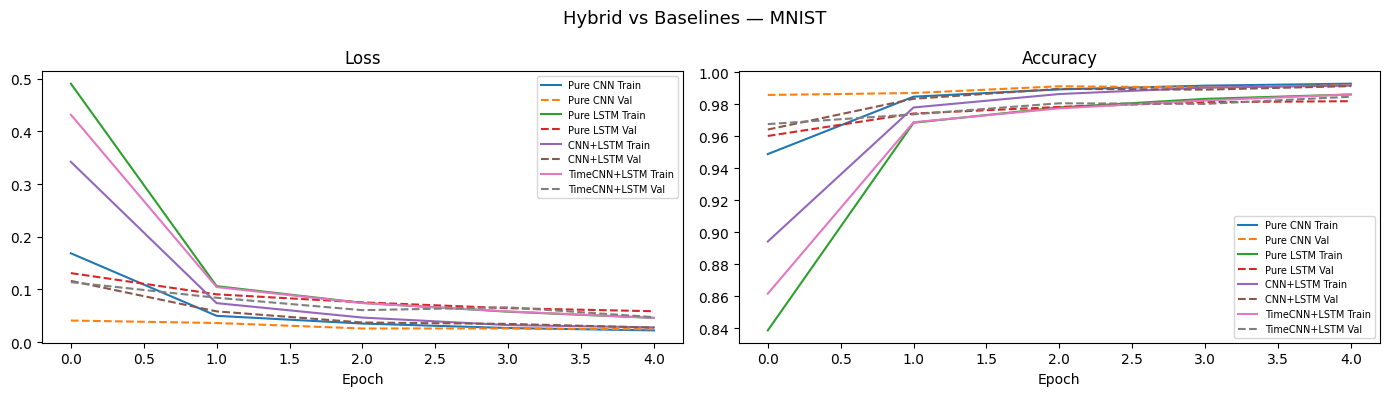

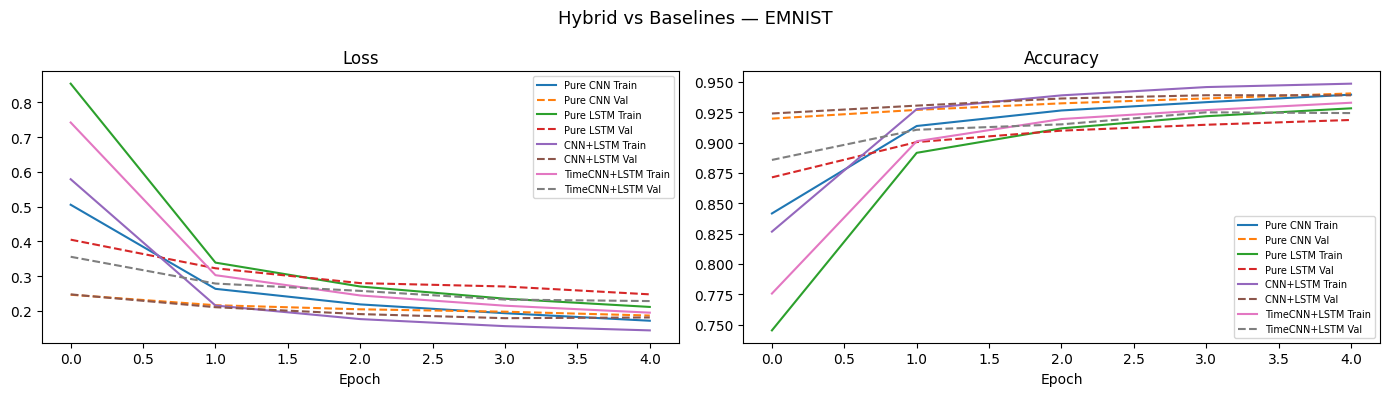

In [37]:
# Hybrid vs Pure CNN vs Pure LSTM
print("\n" + "=" * 60)
print("6.5 HYBRID vs BASELINES COMPARISON")
print("=" * 60)

for dataset_name in ['MNIST', 'EMNIST']:
    plot_history(
        [cnn_lstm_results[(dataset_name, 'PureCNN')],
         lstm_results[(dataset_name, 1, 128, 0.0)],
         cnn_lstm_results[(dataset_name, 'CNN+LSTM')],
         cnn_lstm_results[(dataset_name, 'TimeCNN+LSTM')]],
        ["Pure CNN", "Pure LSTM", "CNN+LSTM", "TimeCNN+LSTM"],
        f"Hybrid vs Baselines — {dataset_name}"
    )

In [38]:
# Parameter & Inference Time Comparison
print("\n" + "=" * 60)
print("6.6 PARAMETERS & INFERENCE TIME — MNIST")
print("=" * 60)

models_to_compare = [
    ("PureCNN",       PureCNN(MNIST_CLASSES)),
    ("PureLSTM",      LSTMModel(INPUT_SIZE, 128, 1, MNIST_CLASSES)),
    ("CNN+LSTM",      CNNLSTMModel(128, 1, MNIST_CLASSES)),
    ("TimeCNN+LSTM",  TimeCNNLSTMModel(128, 1, MNIST_CLASSES)),
]

print(f"\n{'Model':<20} {'Params':>10} {'Inference(ms)':>15}")
print("-" * 48)

imgs_sample, _ = next(iter(mnist_test_loader))
imgs_sample = imgs_sample.to(device)

for name, m in models_to_compare:
    m = m.to(device)
    m.eval()
    params = count_parameters(m)
    # Inference time over 1 batch
    with torch.no_grad():
        t0 = time.time()
        for _ in range(10):
            _ = m(imgs_sample)
        inf_time = (time.time() - t0) / 10 * 1000  # ms
    print(f"{name:<20} {params:>10,} {inf_time:>15.2f}")


6.6 PARAMETERS & INFERENCE TIME — MNIST

Model                    Params   Inference(ms)
------------------------------------------------
PureCNN                 824,458            0.45
PureLSTM                 82,186            0.35
CNN+LSTM                316,042            0.62
TimeCNN+LSTM            184,170            0.57


In [39]:
# Summary Table
print("\n── CNN+LSTM Results Summary ─────────────────────────────")
print(f"{'Dataset':<10} {'Architecture':<20} {'Val Acc':>8}")
print("-" * 40)
for (ds, arch), hist in cnn_lstm_results.items():
    print(f"{ds:<10} {arch:<20} {max(hist['val_acc']):>8.4f}")


── CNN+LSTM Results Summary ─────────────────────────────
Dataset    Architecture          Val Acc
----------------------------------------
MNIST      CNN+LSTM               0.9912
MNIST      TimeCNN+LSTM           0.9846
MNIST      PureCNN                0.9918
EMNIST     CNN+LSTM               0.9390
EMNIST     TimeCNN+LSTM           0.9250
EMNIST     PureCNN                0.9405


# 6) Hyperparameter Tuning & Regularization

In [40]:
# Tuning Config
# We use LSTM on MNIST for all tuning experiments
# (fastest + most comparable across configs)

TUNE_MODEL   = 'LSTM'
TUNE_DATASET = 'MNIST'

tuning_results = {}  # key: (experiment, config_str) → history

# Helper: build & train one config
def tune_run(config_str, hidden_size, num_layers, dropout,
             optimizer_name, lr, train_loader, test_loader,
             num_classes, grad_clip=None):

    model = LSTMModel(INPUT_SIZE, hidden_size, num_layers, num_classes, dropout)
    model.to(device)

    if optimizer_name == 'SGD':
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'Adam':
        opt = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'RMSprop':
        opt = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == 'AdamW':
        opt = optim.AdamW(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(EPOCHS):
        # Train
        model.train()
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        # ── Validate ──
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss    += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / len(test_loader)
        val_acc  = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"  [{config_str}] Epoch {epoch+1}/{EPOCHS} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return history

LEARNING RATE TUNING — LSTM, H=128, L=1

── LR=0.1 ──
  [LR=0.1] Epoch 1/5 | Train Acc: 0.6969 | Val Acc: 0.6520
  [LR=0.1] Epoch 2/5 | Train Acc: 0.5942 | Val Acc: 0.6906
  [LR=0.1] Epoch 3/5 | Train Acc: 0.6540 | Val Acc: 0.6289
  [LR=0.1] Epoch 4/5 | Train Acc: 0.6472 | Val Acc: 0.6618
  [LR=0.1] Epoch 5/5 | Train Acc: 0.6741 | Val Acc: 0.7519

── LR=0.01 ──
  [LR=0.01] Epoch 1/5 | Train Acc: 0.9072 | Val Acc: 0.9616
  [LR=0.01] Epoch 2/5 | Train Acc: 0.9691 | Val Acc: 0.9661
  [LR=0.01] Epoch 3/5 | Train Acc: 0.9713 | Val Acc: 0.9696
  [LR=0.01] Epoch 4/5 | Train Acc: 0.9721 | Val Acc: 0.9680
  [LR=0.01] Epoch 5/5 | Train Acc: 0.9749 | Val Acc: 0.9746

── LR=0.001 ──
  [LR=0.001] Epoch 1/5 | Train Acc: 0.8443 | Val Acc: 0.9621
  [LR=0.001] Epoch 2/5 | Train Acc: 0.9657 | Val Acc: 0.9781
  [LR=0.001] Epoch 3/5 | Train Acc: 0.9772 | Val Acc: 0.9801
  [LR=0.001] Epoch 4/5 | Train Acc: 0.9827 | Val Acc: 0.9796
  [LR=0.001] Epoch 5/5 | Train Acc: 0.9851 | Val Acc: 0.9832

── LR=0.0001 ─

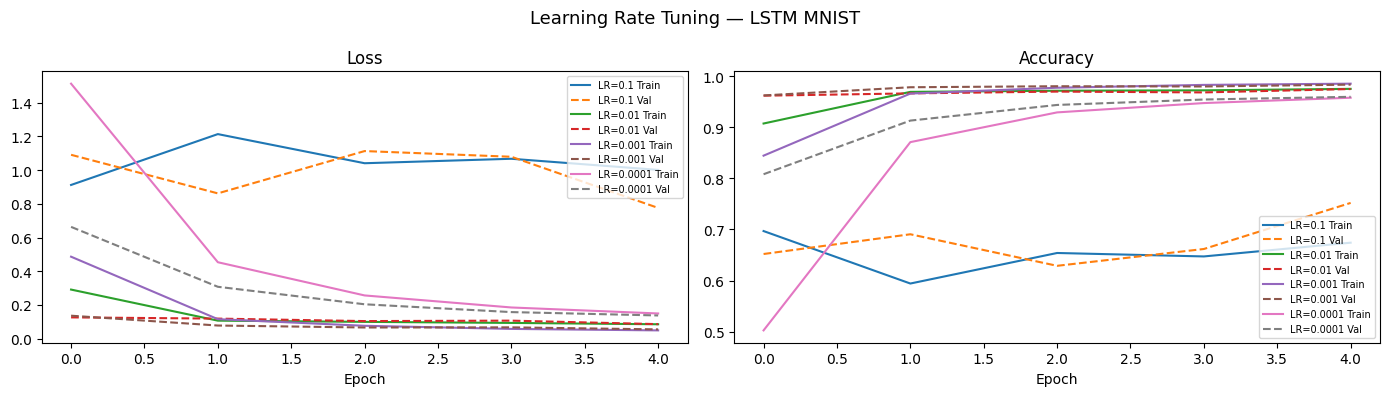

In [41]:
# Learning Rate Tuning
print("=" * 60)
print("LEARNING RATE TUNING — LSTM, H=128, L=1")
print("=" * 60)

lr_values = [0.1, 0.01, 0.001, 0.0001]
for lr in lr_values:
    cfg = f"LR={lr}"
    print(f"\n── {cfg} ──")
    hist = tune_run(cfg, hidden_size=128, num_layers=1, dropout=0.0,
                    optimizer_name='Adam', lr=lr,
                    train_loader=mnist_train_loader,
                    test_loader=mnist_test_loader,
                    num_classes=MNIST_CLASSES)
    tuning_results[('lr', cfg)] = hist

plot_history(
    [tuning_results[('lr', f"LR={lr}")] for lr in lr_values],
    [f"LR={lr}" for lr in lr_values],
    "Learning Rate Tuning — LSTM MNIST"
)


BATCH SIZE TUNING — LSTM, H=128, L=1, LR=0.001

── BS=32 ──
  [BS=32] Epoch 1/5 | Train Acc: 0.9012 | Val Acc: 0.9548
  [BS=32] Epoch 2/5 | Train Acc: 0.9761 | Val Acc: 0.9778
  [BS=32] Epoch 3/5 | Train Acc: 0.9832 | Val Acc: 0.9817
  [BS=32] Epoch 4/5 | Train Acc: 0.9858 | Val Acc: 0.9848
  [BS=32] Epoch 5/5 | Train Acc: 0.9883 | Val Acc: 0.9875

── BS=64 ──
  [BS=64] Epoch 1/5 | Train Acc: 0.8865 | Val Acc: 0.9621
  [BS=64] Epoch 2/5 | Train Acc: 0.9719 | Val Acc: 0.9793
  [BS=64] Epoch 3/5 | Train Acc: 0.9804 | Val Acc: 0.9785
  [BS=64] Epoch 4/5 | Train Acc: 0.9839 | Val Acc: 0.9811
  [BS=64] Epoch 5/5 | Train Acc: 0.9874 | Val Acc: 0.9811

── BS=128 ──
  [BS=128] Epoch 1/5 | Train Acc: 0.8454 | Val Acc: 0.9543
  [BS=128] Epoch 2/5 | Train Acc: 0.9664 | Val Acc: 0.9753
  [BS=128] Epoch 3/5 | Train Acc: 0.9764 | Val Acc: 0.9764
  [BS=128] Epoch 4/5 | Train Acc: 0.9816 | Val Acc: 0.9797
  [BS=128] Epoch 5/5 | Train Acc: 0.9853 | Val Acc: 0.9819

── BS=256 ──
  [BS=256] Epoch 1/5 | 

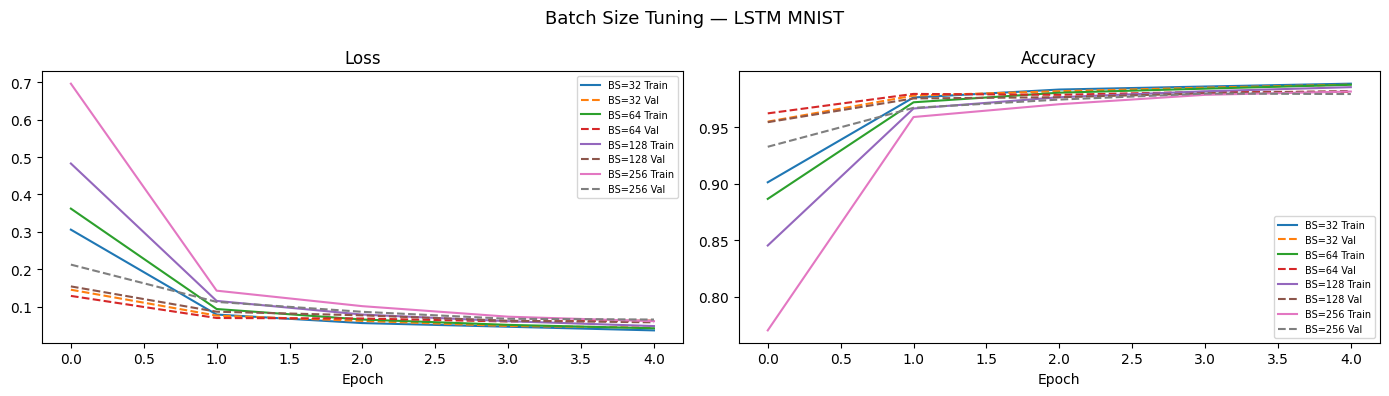

In [42]:
# Batch Size Tuning
print("\n" + "=" * 60)
print("BATCH SIZE TUNING — LSTM, H=128, L=1, LR=0.001")
print("=" * 60)

batch_sizes = [32, 64, 128, 256]
for bs in batch_sizes:
    # Create new loaders with different batch size
    bs_train_loader = DataLoader(mnist_train, batch_size=bs,
                                 shuffle=True,  num_workers=2)
    bs_test_loader  = DataLoader(mnist_test,  batch_size=bs,
                                 shuffle=False, num_workers=2)
    cfg = f"BS={bs}"
    print(f"\n── {cfg} ──")
    hist = tune_run(cfg, hidden_size=128, num_layers=1, dropout=0.0,
                    optimizer_name='Adam', lr=0.001,
                    train_loader=bs_train_loader,
                    test_loader=bs_test_loader,
                    num_classes=MNIST_CLASSES)
    tuning_results[('bs', cfg)] = hist

plot_history(
    [tuning_results[('bs', f"BS={bs}")] for bs in batch_sizes],
    [f"BS={bs}" for bs in batch_sizes],
    "Batch Size Tuning — LSTM MNIST"
)


HIDDEN UNITS TUNING — LSTM, L=1, LR=0.001

── H=32 ──
  [H=32] Epoch 1/5 | Train Acc: 0.6793 | Val Acc: 0.8792
  [H=32] Epoch 2/5 | Train Acc: 0.9079 | Val Acc: 0.9275
  [H=32] Epoch 3/5 | Train Acc: 0.9379 | Val Acc: 0.9494
  [H=32] Epoch 4/5 | Train Acc: 0.9510 | Val Acc: 0.9559
  [H=32] Epoch 5/5 | Train Acc: 0.9593 | Val Acc: 0.9633

── H=64 ──
  [H=64] Epoch 1/5 | Train Acc: 0.7688 | Val Acc: 0.9382
  [H=64] Epoch 2/5 | Train Acc: 0.9542 | Val Acc: 0.9641
  [H=64] Epoch 3/5 | Train Acc: 0.9673 | Val Acc: 0.9717
  [H=64] Epoch 4/5 | Train Acc: 0.9747 | Val Acc: 0.9730
  [H=64] Epoch 5/5 | Train Acc: 0.9784 | Val Acc: 0.9746

── H=128 ──
  [H=128] Epoch 1/5 | Train Acc: 0.8397 | Val Acc: 0.9665
  [H=128] Epoch 2/5 | Train Acc: 0.9690 | Val Acc: 0.9678
  [H=128] Epoch 3/5 | Train Acc: 0.9786 | Val Acc: 0.9774
  [H=128] Epoch 4/5 | Train Acc: 0.9830 | Val Acc: 0.9841
  [H=128] Epoch 5/5 | Train Acc: 0.9854 | Val Acc: 0.9849

── H=256 ──
  [H=256] Epoch 1/5 | Train Acc: 0.8651 | Val A

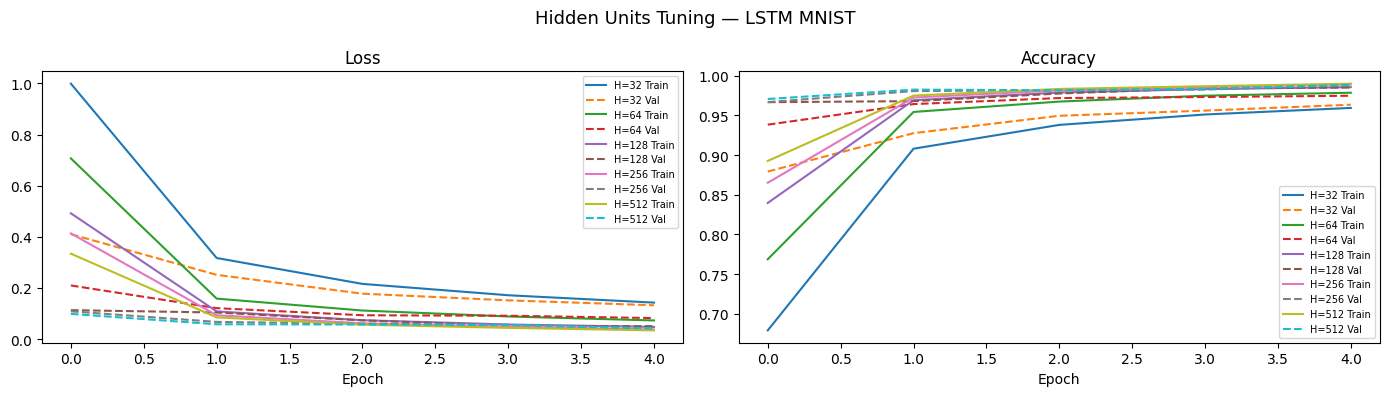

In [43]:
# Hidden Units Tuning
print("\n" + "=" * 60)
print("HIDDEN UNITS TUNING — LSTM, L=1, LR=0.001")
print("=" * 60)

hidden_units = [32, 64, 128, 256, 512]
for hu in hidden_units:
    cfg = f"H={hu}"
    print(f"\n── {cfg} ──")
    hist = tune_run(cfg, hidden_size=hu, num_layers=1, dropout=0.0,
                    optimizer_name='Adam', lr=0.001,
                    train_loader=mnist_train_loader,
                    test_loader=mnist_test_loader,
                    num_classes=MNIST_CLASSES)
    tuning_results[('hu', cfg)] = hist

plot_history(
    [tuning_results[('hu', f"H={hu}")] for hu in hidden_units],
    [f"H={hu}" for hu in hidden_units],
    "Hidden Units Tuning — LSTM MNIST"
)


NUMBER OF LAYERS TUNING — LSTM, H=128, LR=0.001

── L=1 ──
  [L=1] Epoch 1/5 | Train Acc: 0.8358 | Val Acc: 0.9597
  [L=1] Epoch 2/5 | Train Acc: 0.9662 | Val Acc: 0.9715
  [L=1] Epoch 3/5 | Train Acc: 0.9760 | Val Acc: 0.9796
  [L=1] Epoch 4/5 | Train Acc: 0.9815 | Val Acc: 0.9831
  [L=1] Epoch 5/5 | Train Acc: 0.9848 | Val Acc: 0.9823

── L=2 ──
  [L=2] Epoch 1/5 | Train Acc: 0.8656 | Val Acc: 0.9536
  [L=2] Epoch 2/5 | Train Acc: 0.9697 | Val Acc: 0.9786
  [L=2] Epoch 3/5 | Train Acc: 0.9780 | Val Acc: 0.9802
  [L=2] Epoch 4/5 | Train Acc: 0.9832 | Val Acc: 0.9822
  [L=2] Epoch 5/5 | Train Acc: 0.9867 | Val Acc: 0.9830

── L=3 ──
  [L=3] Epoch 1/5 | Train Acc: 0.8631 | Val Acc: 0.9631
  [L=3] Epoch 2/5 | Train Acc: 0.9722 | Val Acc: 0.9767
  [L=3] Epoch 3/5 | Train Acc: 0.9807 | Val Acc: 0.9832
  [L=3] Epoch 4/5 | Train Acc: 0.9842 | Val Acc: 0.9855
  [L=3] Epoch 5/5 | Train Acc: 0.9866 | Val Acc: 0.9865

── L=4 ──
  [L=4] Epoch 1/5 | Train Acc: 0.8413 | Val Acc: 0.9627
  [L=4] Epo

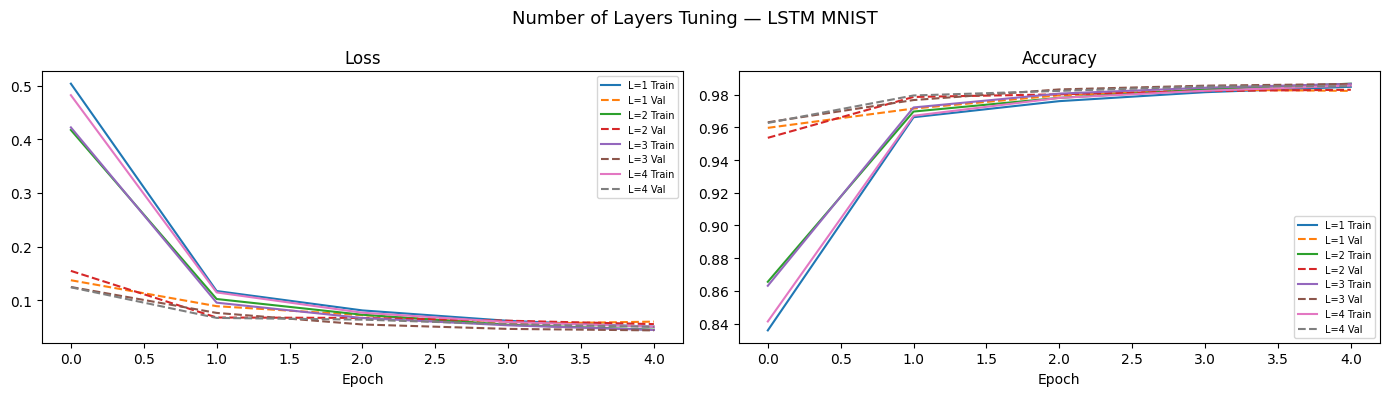

In [44]:
# Number of Layers Tuning
print("\n" + "=" * 60)
print("NUMBER OF LAYERS TUNING — LSTM, H=128, LR=0.001")
print("=" * 60)

num_layers_list = [1, 2, 3, 4]
for nl in num_layers_list:
    cfg = f"L={nl}"
    print(f"\n── {cfg} ──")
    hist = tune_run(cfg, hidden_size=128, num_layers=nl, dropout=0.2,
                    optimizer_name='Adam', lr=0.001,
                    train_loader=mnist_train_loader,
                    test_loader=mnist_test_loader,
                    num_classes=MNIST_CLASSES)
    tuning_results[('nl', cfg)] = hist

plot_history(
    [tuning_results[('nl', f"L={nl}")] for nl in num_layers_list],
    [f"L={nl}" for nl in num_layers_list],
    "Number of Layers Tuning — LSTM MNIST"
)


OPTIMIZER TUNING — LSTM, H=128, L=1, LR=0.001

── Opt=SGD ──
  [Opt=SGD] Epoch 1/5 | Train Acc: 0.1295 | Val Acc: 0.1613
  [Opt=SGD] Epoch 2/5 | Train Acc: 0.1681 | Val Acc: 0.1754
  [Opt=SGD] Epoch 3/5 | Train Acc: 0.1807 | Val Acc: 0.1903
  [Opt=SGD] Epoch 4/5 | Train Acc: 0.1930 | Val Acc: 0.2007
  [Opt=SGD] Epoch 5/5 | Train Acc: 0.2415 | Val Acc: 0.2998

── Opt=Adam ──
  [Opt=Adam] Epoch 1/5 | Train Acc: 0.8462 | Val Acc: 0.9595
  [Opt=Adam] Epoch 2/5 | Train Acc: 0.9677 | Val Acc: 0.9717
  [Opt=Adam] Epoch 3/5 | Train Acc: 0.9781 | Val Acc: 0.9796
  [Opt=Adam] Epoch 4/5 | Train Acc: 0.9834 | Val Acc: 0.9786
  [Opt=Adam] Epoch 5/5 | Train Acc: 0.9865 | Val Acc: 0.9840

── Opt=RMSprop ──
  [Opt=RMSprop] Epoch 1/5 | Train Acc: 0.8840 | Val Acc: 0.9590
  [Opt=RMSprop] Epoch 2/5 | Train Acc: 0.9694 | Val Acc: 0.9693
  [Opt=RMSprop] Epoch 3/5 | Train Acc: 0.9790 | Val Acc: 0.9807
  [Opt=RMSprop] Epoch 4/5 | Train Acc: 0.9841 | Val Acc: 0.9811
  [Opt=RMSprop] Epoch 5/5 | Train Acc: 0.9

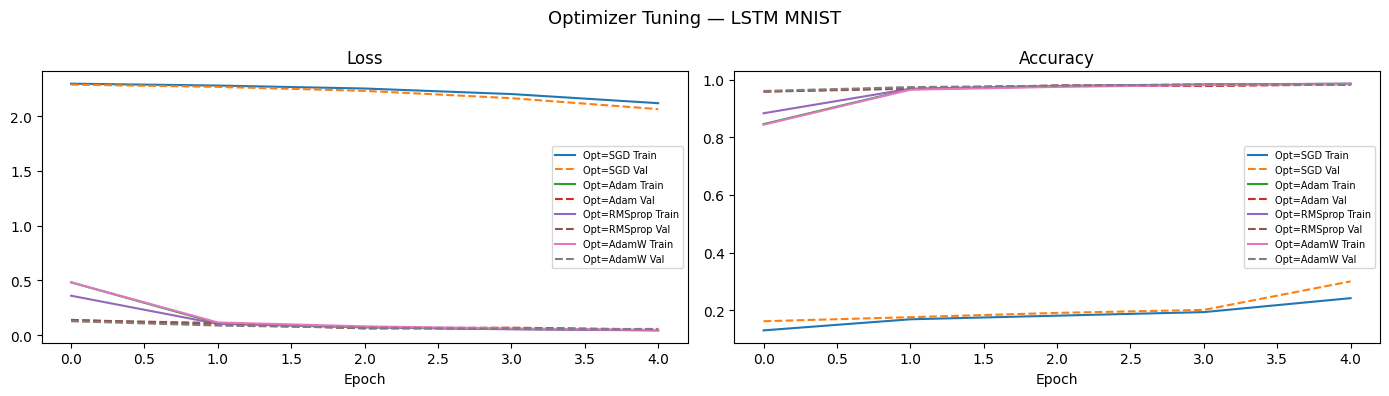

In [45]:
# Optimizer Tuning
print("\n" + "=" * 60)
print("OPTIMIZER TUNING — LSTM, H=128, L=1, LR=0.001")
print("=" * 60)

optimizers = ['SGD', 'Adam', 'RMSprop', 'AdamW']
for opt_name in optimizers:
    cfg = f"Opt={opt_name}"
    print(f"\n── {cfg} ──")
    hist = tune_run(cfg, hidden_size=128, num_layers=1, dropout=0.0,
                    optimizer_name=opt_name, lr=0.001,
                    train_loader=mnist_train_loader,
                    test_loader=mnist_test_loader,
                    num_classes=MNIST_CLASSES)
    tuning_results[('opt', cfg)] = hist

plot_history(
    [tuning_results[('opt', f"Opt={o}")] for o in optimizers],
    [f"Opt={o}" for o in optimizers],
    "Optimizer Tuning — LSTM MNIST"
)


GRADIENT CLIPPING — LSTM, H=128, L=1, LR=0.001

── Clip=None ──
  [Clip=None] Epoch 1/5 | Train Acc: 0.8427 | Val Acc: 0.9587
  [Clip=None] Epoch 2/5 | Train Acc: 0.9681 | Val Acc: 0.9713
  [Clip=None] Epoch 3/5 | Train Acc: 0.9778 | Val Acc: 0.9761
  [Clip=None] Epoch 4/5 | Train Acc: 0.9834 | Val Acc: 0.9830
  [Clip=None] Epoch 5/5 | Train Acc: 0.9860 | Val Acc: 0.9844

── Clip=1.0 ──
  [Clip=1.0] Epoch 1/5 | Train Acc: 0.8387 | Val Acc: 0.9614
  [Clip=1.0] Epoch 2/5 | Train Acc: 0.9647 | Val Acc: 0.9716
  [Clip=1.0] Epoch 3/5 | Train Acc: 0.9768 | Val Acc: 0.9794
  [Clip=1.0] Epoch 4/5 | Train Acc: 0.9825 | Val Acc: 0.9804
  [Clip=1.0] Epoch 5/5 | Train Acc: 0.9856 | Val Acc: 0.9831

── Clip=5.0 ──
  [Clip=5.0] Epoch 1/5 | Train Acc: 0.8511 | Val Acc: 0.9643
  [Clip=5.0] Epoch 2/5 | Train Acc: 0.9660 | Val Acc: 0.9696
  [Clip=5.0] Epoch 3/5 | Train Acc: 0.9774 | Val Acc: 0.9682
  [Clip=5.0] Epoch 4/5 | Train Acc: 0.9813 | Val Acc: 0.9767
  [Clip=5.0] Epoch 5/5 | Train Acc: 0.9847 |

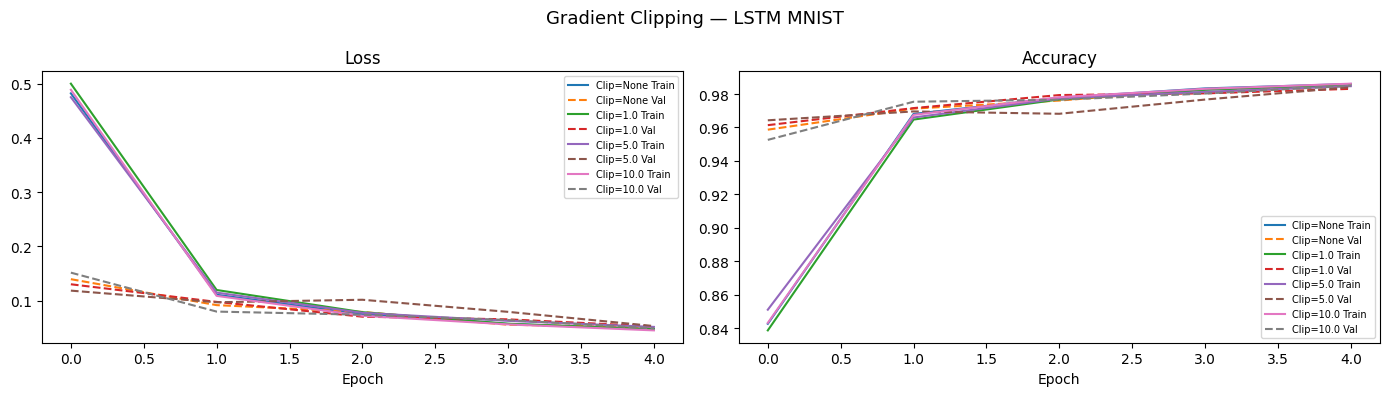

In [46]:
# Gradient Clipping Tuning
print("\n" + "=" * 60)
print("GRADIENT CLIPPING — LSTM, H=128, L=1, LR=0.001")
print("=" * 60)

clip_values = [None, 1.0, 5.0, 10.0]
for clip in clip_values:
    cfg = f"Clip={clip}"
    print(f"\n── {cfg} ──")
    hist = tune_run(cfg, hidden_size=128, num_layers=1, dropout=0.0,
                    optimizer_name='Adam', lr=0.001,
                    train_loader=mnist_train_loader,
                    test_loader=mnist_test_loader,
                    num_classes=MNIST_CLASSES,
                    grad_clip=clip)
    tuning_results[('clip', cfg)] = hist

plot_history(
    [tuning_results[('clip', f"Clip={c}")] for c in clip_values],
    [f"Clip={c}" for c in clip_values],
    "Gradient Clipping — LSTM MNIST"
)


L2 REGULARIZATION (Weight Decay) — LSTM, H=128, L=1

── WD=0.0 ──
[WD=0.0] Epoch 1/5 | Train Loss: 0.5166 Acc: 0.8328 | Val Loss: 0.1562 Acc: 0.9536
[WD=0.0] Epoch 2/5 | Train Loss: 0.1150 Acc: 0.9661 | Val Loss: 0.0918 Acc: 0.9723
[WD=0.0] Epoch 3/5 | Train Loss: 0.0805 Acc: 0.9759 | Val Loss: 0.0830 Acc: 0.9760
[WD=0.0] Epoch 4/5 | Train Loss: 0.0618 Acc: 0.9817 | Val Loss: 0.0657 Acc: 0.9799
[WD=0.0] Epoch 5/5 | Train Loss: 0.0498 Acc: 0.9855 | Val Loss: 0.0544 Acc: 0.9830

── WD=0.0001 ──
[WD=0.0001] Epoch 1/5 | Train Loss: 0.4680 Acc: 0.8497 | Val Loss: 0.1337 Acc: 0.9606
[WD=0.0001] Epoch 2/5 | Train Loss: 0.1086 Acc: 0.9681 | Val Loss: 0.0878 Acc: 0.9718
[WD=0.0001] Epoch 3/5 | Train Loss: 0.0748 Acc: 0.9776 | Val Loss: 0.0842 Acc: 0.9728
[WD=0.0001] Epoch 4/5 | Train Loss: 0.0586 Acc: 0.9825 | Val Loss: 0.0822 Acc: 0.9746
[WD=0.0001] Epoch 5/5 | Train Loss: 0.0502 Acc: 0.9849 | Val Loss: 0.0598 Acc: 0.9814

── WD=0.001 ──
[WD=0.001] Epoch 1/5 | Train Loss: 0.5407 Acc: 0.8248 |

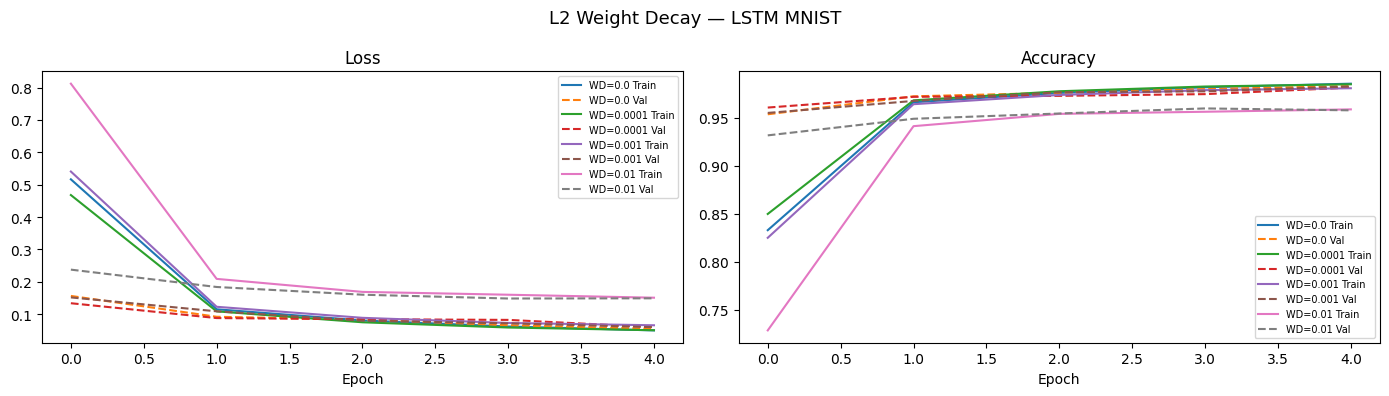

In [47]:
# Regularization: L2 Weight Decay
print("\n" + "=" * 60)
print("L2 REGULARIZATION (Weight Decay) — LSTM, H=128, L=1")
print("=" * 60)

wd_values = [0.0, 1e-4, 1e-3, 1e-2]
wd_results = {}

for wd in wd_values:
    cfg = f"WD={wd}"
    print(f"\n── {cfg} ──")
    model = LSTMModel(INPUT_SIZE, 128, 1, MNIST_CLASSES, dropout=0.0).to(device)
    opt   = optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)
    hist  = train_model(model, mnist_train_loader, mnist_test_loader,
                        opt, criterion, EPOCHS, cfg)
    wd_results[cfg] = hist

plot_history(
    [wd_results[f"WD={wd}"] for wd in wd_values],
    [f"WD={wd}" for wd in wd_values],
    "L2 Weight Decay — LSTM MNIST"
)


LR SCHEDULING — LSTM, H=128, L=1

── Scheduler=None ──
  [Sched=None] Epoch 1/5 | Train Acc: 0.8496 | Val Acc: 0.9620
  [Sched=None] Epoch 2/5 | Train Acc: 0.9687 | Val Acc: 0.9772
  [Sched=None] Epoch 3/5 | Train Acc: 0.9790 | Val Acc: 0.9799
  [Sched=None] Epoch 4/5 | Train Acc: 0.9842 | Val Acc: 0.9826
  [Sched=None] Epoch 5/5 | Train Acc: 0.9869 | Val Acc: 0.9837

── Scheduler=StepLR ──
  [Sched=StepLR] Epoch 1/5 | Train Acc: 0.8477 | Val Acc: 0.9633
  [Sched=StepLR] Epoch 2/5 | Train Acc: 0.9657 | Val Acc: 0.9673
  [Sched=StepLR] Epoch 3/5 | Train Acc: 0.9804 | Val Acc: 0.9802
  [Sched=StepLR] Epoch 4/5 | Train Acc: 0.9838 | Val Acc: 0.9803
  [Sched=StepLR] Epoch 5/5 | Train Acc: 0.9888 | Val Acc: 0.9823

── Scheduler=CosineAnnealing ──
  [Sched=CosineAnnealing] Epoch 1/5 | Train Acc: 0.8452 | Val Acc: 0.9591
  [Sched=CosineAnnealing] Epoch 2/5 | Train Acc: 0.9684 | Val Acc: 0.9748
  [Sched=CosineAnnealing] Epoch 3/5 | Train Acc: 0.9793 | Val Acc: 0.9802
  [Sched=CosineAnnealing]

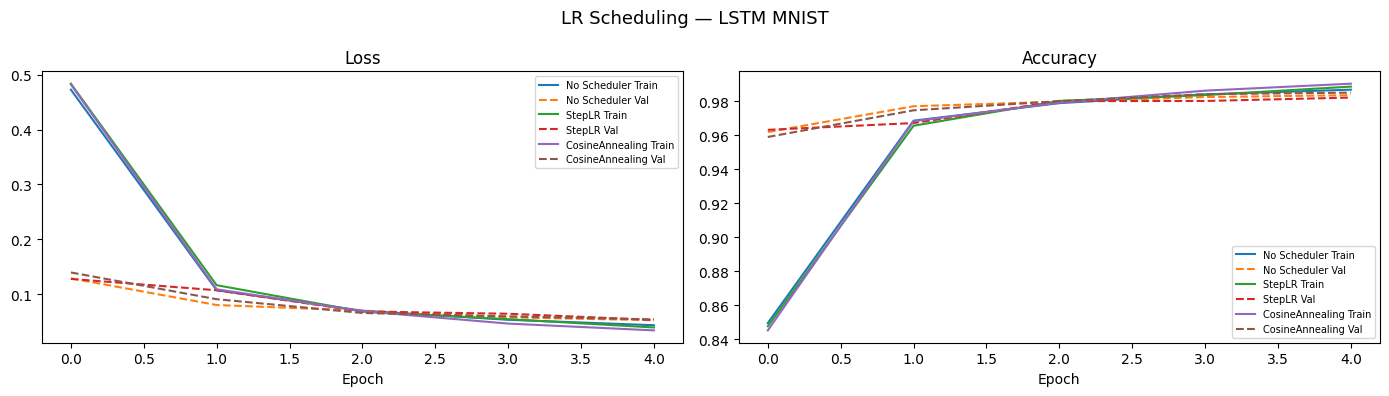

In [48]:
# Regularization: LR Scheduling
print("\n" + "=" * 60)
print("LR SCHEDULING — LSTM, H=128, L=1")
print("=" * 60)

scheduler_results = {}

for sched_name in ['None', 'StepLR', 'CosineAnnealing']:
    print(f"\n── Scheduler={sched_name} ──")
    model = LSTMModel(INPUT_SIZE, 128, 1, MNIST_CLASSES, dropout=0.0).to(device)
    opt   = optim.Adam(model.parameters(), lr=0.001)

    if sched_name == 'StepLR':
        scheduler = optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.5)
    elif sched_name == 'CosineAnnealing':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    else:
        scheduler = None

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(EPOCHS):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in mnist_train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            opt.step()
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

        if scheduler is not None:
            scheduler.step()

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in mnist_test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss    += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / len(mnist_test_loader)
        val_acc  = val_correct / val_total
        train_loss = total_loss / len(mnist_train_loader)
        train_acc  = correct / total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"  [Sched={sched_name}] Epoch {epoch+1}/{EPOCHS} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    scheduler_results[sched_name] = history

plot_history(
    [scheduler_results[s] for s in ['None', 'StepLR', 'CosineAnnealing']],
    ['No Scheduler', 'StepLR', 'CosineAnnealing'],
    "LR Scheduling — LSTM MNIST"
)

In [49]:
# Summary Table
print("\n── Tuning Summary ───────────────────────────────────────")
print(f"{'Experiment':<12} {'Config':<20} {'Best Val Acc':>12}")
print("-" * 46)
for (exp, cfg), hist in tuning_results.items():
    print(f"{exp:<12} {cfg:<20} {max(hist['val_acc']):>12.4f}")


── Tuning Summary ───────────────────────────────────────
Experiment   Config               Best Val Acc
----------------------------------------------
lr           LR=0.1                     0.7519
lr           LR=0.01                    0.9746
lr           LR=0.001                   0.9832
lr           LR=0.0001                  0.9594
bs           BS=32                      0.9875
bs           BS=64                      0.9811
bs           BS=128                     0.9819
bs           BS=256                     0.9796
hu           H=32                       0.9633
hu           H=64                       0.9746
hu           H=128                      0.9849
hu           H=256                      0.9878
hu           H=512                      0.9883
nl           L=1                        0.9831
nl           L=2                        0.9830
nl           L=3                        0.9865
nl           L=4                        0.9852
opt          Opt=SGD                    0.2998
o

## 7) Comprehensive Comparative Analysis

In [50]:
# Collect All Best Results
def get_param_count(model_name, dataset):
    num_classes = MNIST_CLASSES if dataset == 'MNIST' else EMNIST_CLASSES
    if model_name == 'VanillaRNN':
        return count_parameters(VanillaRNN(INPUT_SIZE, 128, 1, num_classes))
    elif model_name == 'LSTM':
        return count_parameters(LSTMModel(INPUT_SIZE, 128, 1, num_classes))
    elif model_name == 'GRU':
        return count_parameters(GRUModel(INPUT_SIZE, 128, 1, num_classes))
    elif model_name == 'BiLSTM':
        return count_parameters(BiLSTMModel(INPUT_SIZE, 128, 1, num_classes))
    elif model_name == 'BiGRU':
        return count_parameters(BiGRUModel(INPUT_SIZE, 128, 1, num_classes))
    elif model_name == 'CNN+LSTM':
        return count_parameters(CNNLSTMModel(128, 1, num_classes))
    elif model_name == 'TimeCNN+LSTM':
        return count_parameters(TimeCNNLSTMModel(128, 1, num_classes))
    elif model_name == 'PureCNN':
        return count_parameters(PureCNN(num_classes))

all_models = [
    ('VanillaRNN',   rnn_results[('MNIST',  1, 128)],           rnn_results[('EMNIST',  1, 128)]),
    ('LSTM',         lstm_results[('MNIST',  1, 128, 0.0)],      lstm_results[('EMNIST',  1, 128, 0.0)]),
    ('GRU',          gru_results[('MNIST',   1, 128, 0.0)],      gru_results[('EMNIST',   1, 128, 0.0)]),
    ('BiLSTM',       bilstm_results[('MNIST', 'concat')],        bilstm_results[('EMNIST', 'concat')]),
    ('BiGRU',        bigru_results[('MNIST',  'concat')],        bigru_results[('EMNIST',  'concat')]),
    ('CNN+LSTM',     cnn_lstm_results[('MNIST', 'CNN+LSTM')],    cnn_lstm_results[('EMNIST', 'CNN+LSTM')]),
    ('TimeCNN+LSTM', cnn_lstm_results[('MNIST', 'TimeCNN+LSTM')],cnn_lstm_results[('EMNIST', 'TimeCNN+LSTM')]),
    ('PureCNN',      cnn_lstm_results[('MNIST', 'PureCNN')],     cnn_lstm_results[('EMNIST', 'PureCNN')]),
]

TRAIN/VAL CURVES — ALL MODELS


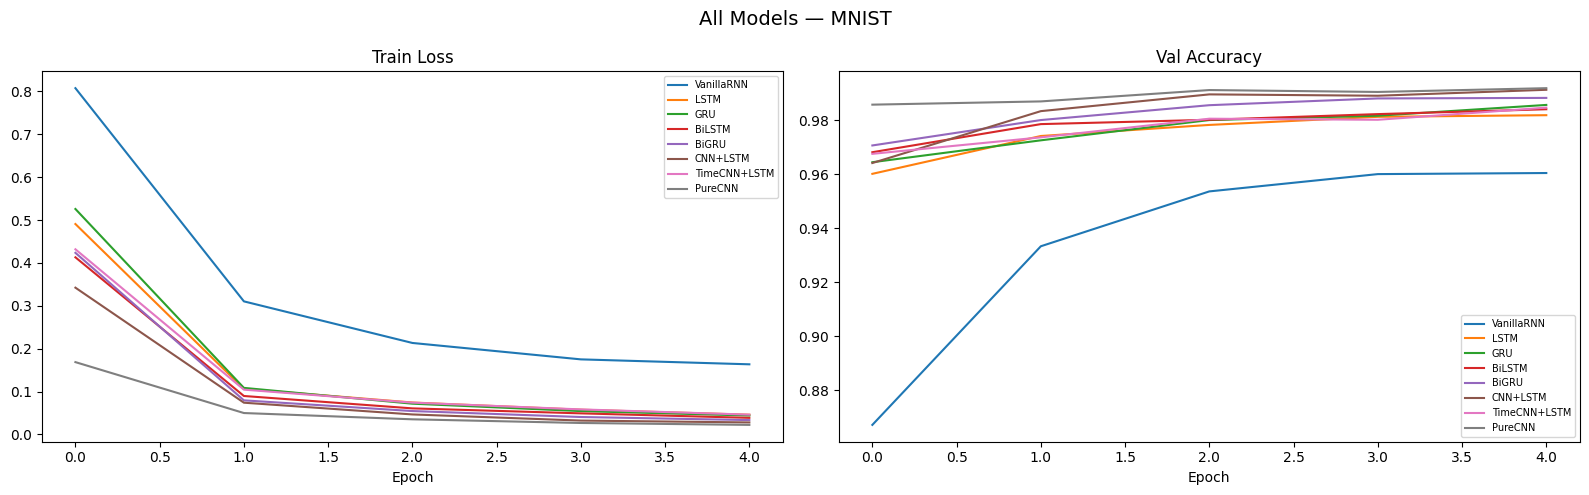

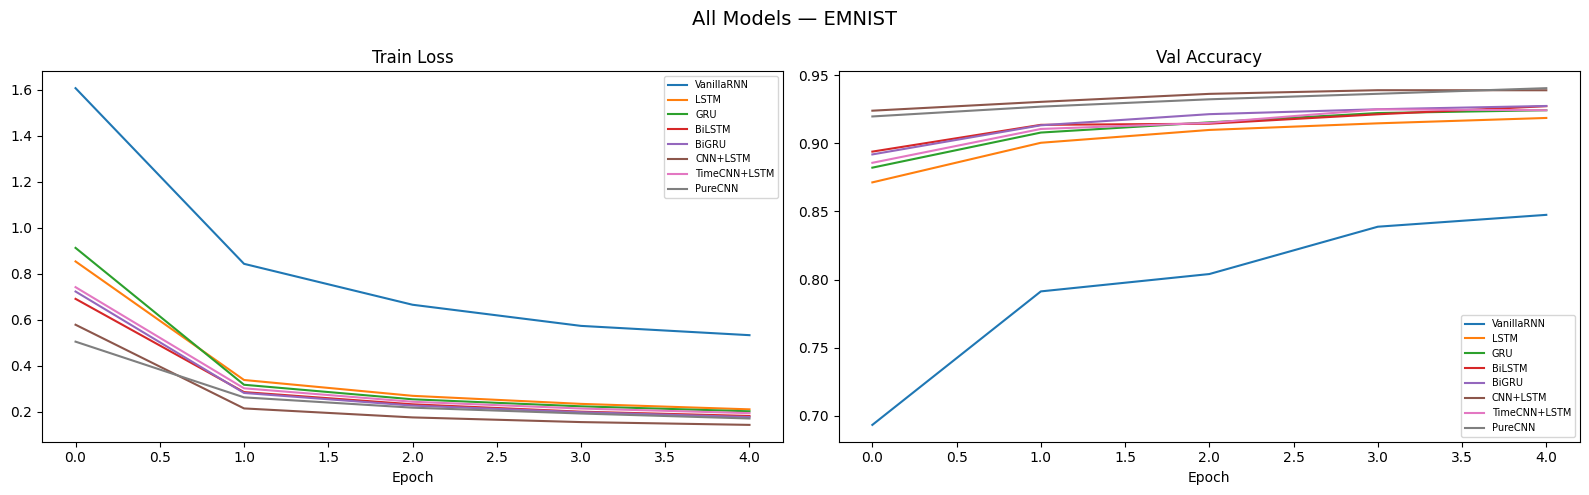

In [51]:
# Training/Validation Curves — All Models
print("=" * 60)
print("TRAIN/VAL CURVES — ALL MODELS")
print("=" * 60)

for dataset_name, hist_idx in [('MNIST', 1), ('EMNIST', 2)]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"All Models — {dataset_name}", fontsize=14)
    for name, mnist_hist, emnist_hist in all_models:
        hist = mnist_hist if dataset_name == 'MNIST' else emnist_hist
        axes[0].plot(hist['train_loss'], label=name)
        axes[1].plot(hist['val_acc'],    label=name)
    axes[0].set_title("Train Loss");  axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=7)
    axes[1].set_title("Val Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=7)
    plt.tight_layout()
    plt.show()


CONFUSION MATRICES

Training best model (LSTM L=1 H=128) for confusion matrix...
[BestLSTM-MNIST] Epoch 1/5 | Train Loss: 0.4819 Acc: 0.8469 | Val Loss: 0.1590 Acc: 0.9525
[BestLSTM-MNIST] Epoch 2/5 | Train Loss: 0.1141 Acc: 0.9663 | Val Loss: 0.0878 Acc: 0.9740
[BestLSTM-MNIST] Epoch 3/5 | Train Loss: 0.0799 Acc: 0.9766 | Val Loss: 0.0675 Acc: 0.9791
[BestLSTM-MNIST] Epoch 4/5 | Train Loss: 0.0604 Acc: 0.9820 | Val Loss: 0.0564 Acc: 0.9828
[BestLSTM-MNIST] Epoch 5/5 | Train Loss: 0.0497 Acc: 0.9851 | Val Loss: 0.0634 Acc: 0.9821


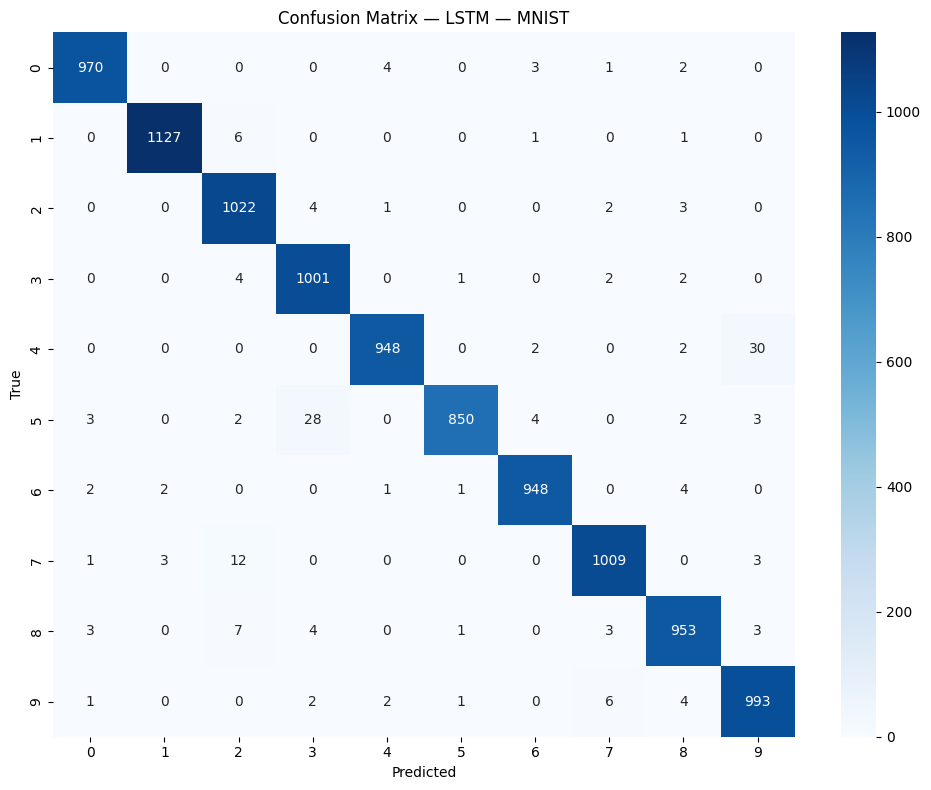

[BestLSTM-EMNIST] Epoch 1/5 | Train Loss: 0.8432 Acc: 0.7488 | Val Loss: 0.4074 Acc: 0.8742
[BestLSTM-EMNIST] Epoch 2/5 | Train Loss: 0.3288 Acc: 0.8954 | Val Loss: 0.3075 Acc: 0.9025
[BestLSTM-EMNIST] Epoch 3/5 | Train Loss: 0.2665 Acc: 0.9132 | Val Loss: 0.2785 Acc: 0.9113
[BestLSTM-EMNIST] Epoch 4/5 | Train Loss: 0.2309 Acc: 0.9233 | Val Loss: 0.2723 Acc: 0.9113
[BestLSTM-EMNIST] Epoch 5/5 | Train Loss: 0.2104 Acc: 0.9297 | Val Loss: 0.2485 Acc: 0.9179


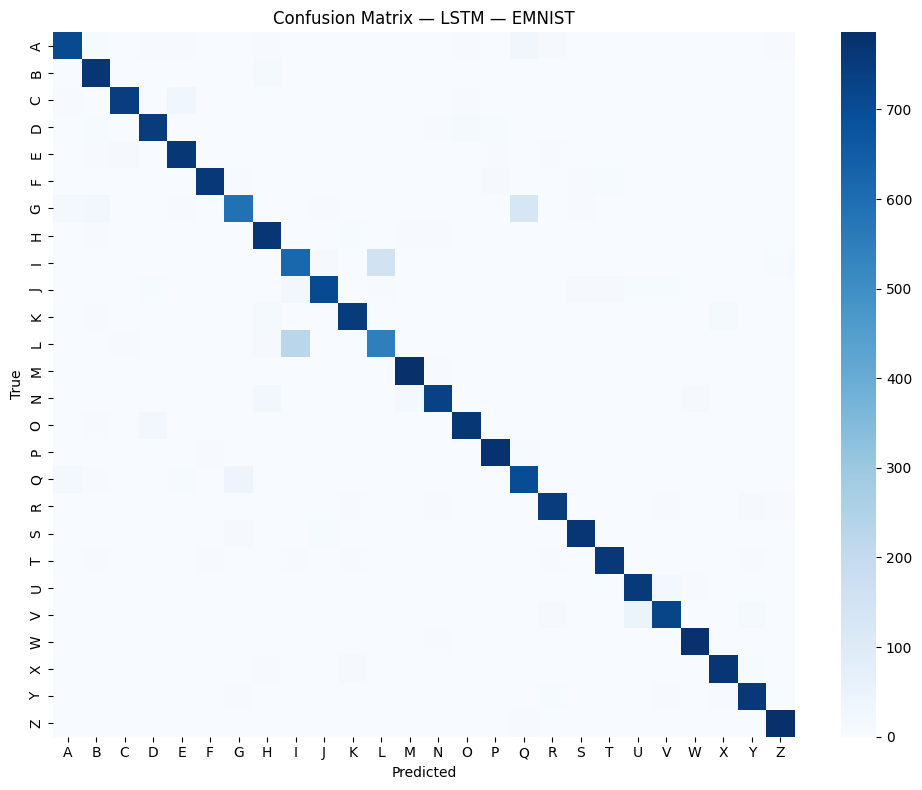

In [52]:
# Confusion Matrices
print("\n" + "=" * 60)
print("CONFUSION MATRICES")
print("=" * 60)

def get_predictions(model, loader):
    model.to(device)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

def plot_confusion_matrix(y_true, y_pred, title, class_names=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=len(cm) <= 15, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

# Train best model per dataset for confusion matrix
# Best = LSTM (L=1, H=128) — consistently strong across sections
print("\nTraining best model (LSTM L=1 H=128) for confusion matrix...")

for dataset_name, train_loader, test_loader, num_classes, label_map in [
    ('MNIST',  mnist_train_loader,  mnist_test_loader,  MNIST_CLASSES,
     [str(i) for i in range(10)]),
    ('EMNIST', emnist_train_loader, emnist_test_loader, EMNIST_CLASSES,
     [chr(65+i) for i in range(26)]),
]:
    best_model = LSTMModel(INPUT_SIZE, 128, 1, num_classes, dropout=0.0)
    opt        = optim.Adam(best_model.parameters(), lr=0.001)
    train_model(best_model, train_loader, test_loader,
                opt, criterion, EPOCHS, f"BestLSTM-{dataset_name}")
    y_true, y_pred = get_predictions(best_model, test_loader)
    plot_confusion_matrix(y_true, y_pred,
                          f"Confusion Matrix — LSTM — {dataset_name}",
                          class_names=label_map)


COMPARISON BAR CHARTS


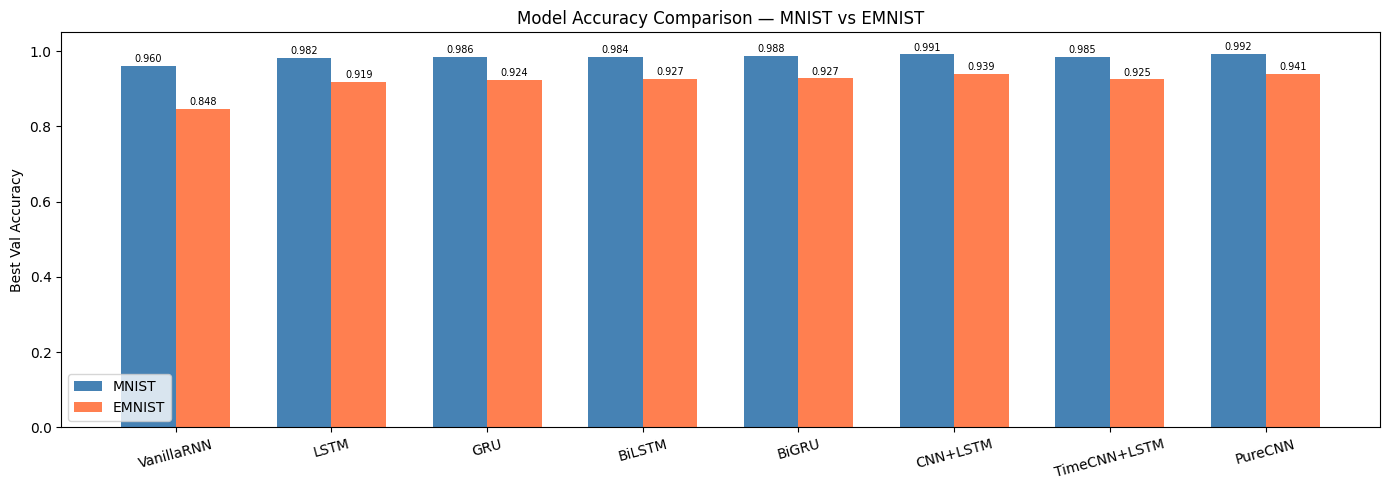

/tmp/ipykernel_24/3364615384.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15)


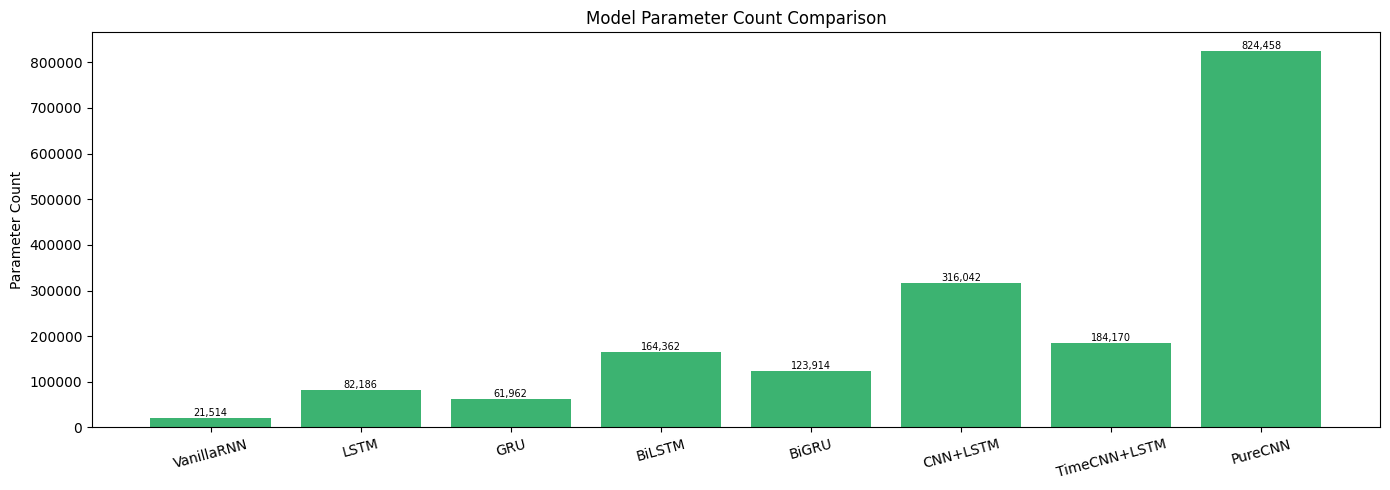

In [53]:
# Comparison Bar Charts
print("\n" + "=" * 60)
print("COMPARISON BAR CHARTS")
print("=" * 60)

model_names  = [m[0] for m in all_models]
mnist_accs   = [max(m[1]['val_acc'])  for m in all_models]
emnist_accs  = [max(m[2]['val_acc'])  for m in all_models]
mnist_params = [get_param_count(m[0], 'MNIST')  for m in all_models]

x = np.arange(len(model_names))
width = 0.35

# Accuracy comparison
fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - width/2, mnist_accs,  width, label='MNIST',  color='steelblue')
bars2 = ax.bar(x + width/2, emnist_accs, width, label='EMNIST', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel("Best Val Accuracy")
ax.set_title("Model Accuracy Comparison — MNIST vs EMNIST")
ax.legend()
ax.set_ylim(0, 1.05)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

# Parameter count comparison
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(model_names, mnist_params, color='mediumseagreen')
ax.set_ylabel("Parameter Count")
ax.set_title("Model Parameter Count Comparison")
ax.set_xticklabels(model_names, rotation=15)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()


INFERENCE TIME COMPARISON — MNIST
  VanillaRNN           0.31 ms
  LSTM                 0.31 ms
  GRU                  0.56 ms
  BiLSTM               0.40 ms
  BiGRU                0.38 ms
  CNN+LSTM             0.61 ms
  TimeCNN+LSTM         0.54 ms
  PureCNN              0.52 ms


/tmp/ipykernel_24/1809714964.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m[0] for m in inference_models], rotation=15)


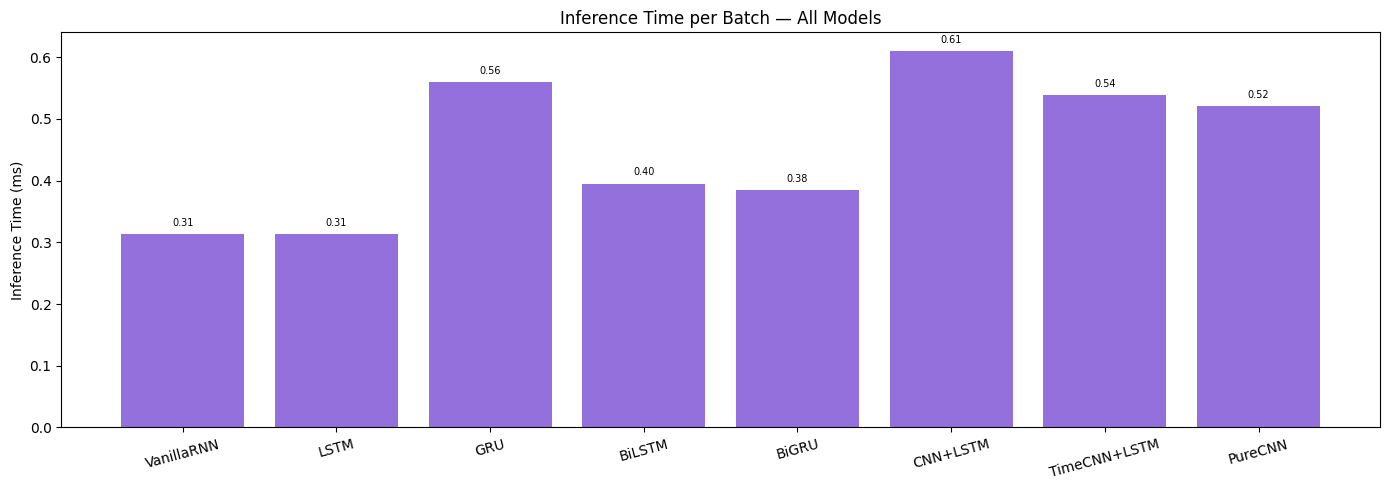

In [54]:
# Inference Time Comparison
print("\n" + "=" * 60)
print("INFERENCE TIME COMPARISON — MNIST")
print("=" * 60)

inference_models = [
    ('VanillaRNN',   VanillaRNN(INPUT_SIZE, 128, 1, MNIST_CLASSES)),
    ('LSTM',         LSTMModel(INPUT_SIZE, 128, 1, MNIST_CLASSES)),
    ('GRU',          GRUModel(INPUT_SIZE, 128, 1, MNIST_CLASSES)),
    ('BiLSTM',       BiLSTMModel(INPUT_SIZE, 128, 1, MNIST_CLASSES)),
    ('BiGRU',        BiGRUModel(INPUT_SIZE, 128, 1, MNIST_CLASSES)),
    ('CNN+LSTM',     CNNLSTMModel(128, 1, MNIST_CLASSES)),
    ('TimeCNN+LSTM', TimeCNNLSTMModel(128, 1, MNIST_CLASSES)),
    ('PureCNN',      PureCNN(MNIST_CLASSES)),
]

imgs_sample, _ = next(iter(mnist_test_loader))
imgs_sample = imgs_sample.to(device)

inf_times = []
for name, m in inference_models:
    m = m.to(device)
    m.eval()
    with torch.no_grad():
        t0 = time.time()
        for _ in range(20):
            _ = m(imgs_sample)
        inf_ms = (time.time() - t0) / 20 * 1000
    inf_times.append(inf_ms)
    print(f"  {name:<20} {inf_ms:.2f} ms")

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar([m[0] for m in inference_models], inf_times, color='mediumpurple')
ax.set_ylabel("Inference Time (ms)")
ax.set_title("Inference Time per Batch — All Models")
ax.set_xticklabels([m[0] for m in inference_models], rotation=15)
for bar, t in zip(bars, inf_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{t:.2f}", ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()


t-SNE FEATURE VISUALIZATION — LSTM MNIST
[LSTM-tSNE] Epoch 1/5 | Train Loss: 0.4824 Acc: 0.8439 | Val Loss: 0.1525 Acc: 0.9541
[LSTM-tSNE] Epoch 2/5 | Train Loss: 0.1117 Acc: 0.9670 | Val Loss: 0.0938 Acc: 0.9736
[LSTM-tSNE] Epoch 3/5 | Train Loss: 0.0725 Acc: 0.9782 | Val Loss: 0.0663 Acc: 0.9801
[LSTM-tSNE] Epoch 4/5 | Train Loss: 0.0534 Acc: 0.9842 | Val Loss: 0.0567 Acc: 0.9829
[LSTM-tSNE] Epoch 5/5 | Train Loss: 0.0448 Acc: 0.9865 | Val Loss: 0.0601 Acc: 0.9811
Running t-SNE...


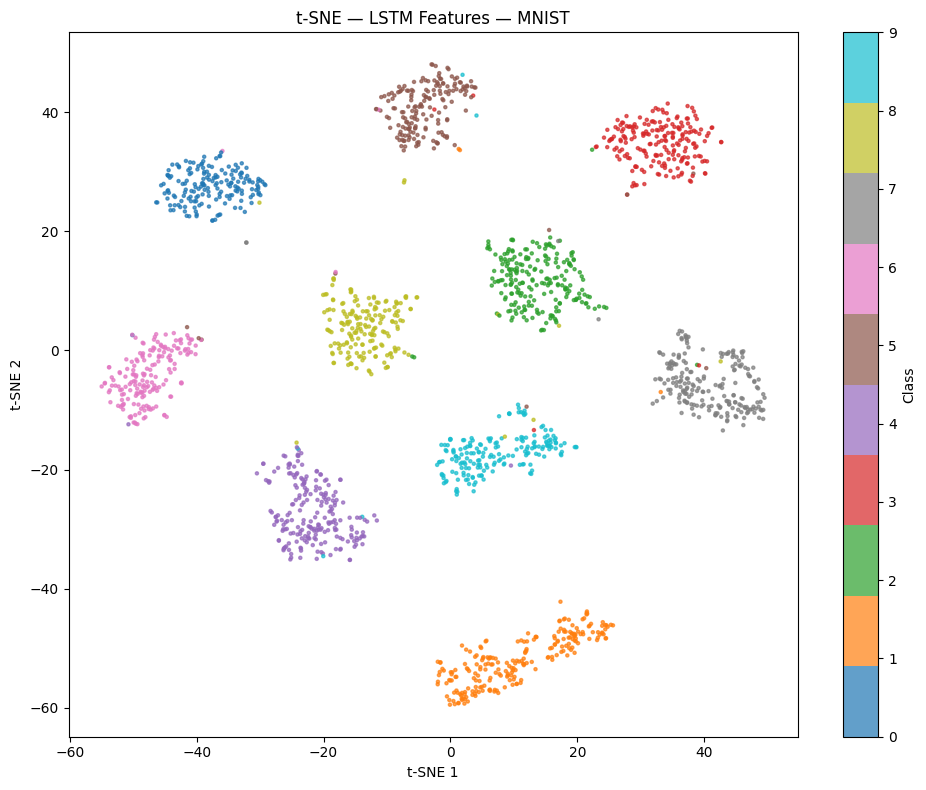

In [55]:
# t-SNE Visualization
print("\n" + "=" * 60)
print("t-SNE FEATURE VISUALIZATION — LSTM MNIST")
print("=" * 60)

def extract_features(model, loader, max_samples=2000):
    model.to(device)
    model.eval()
    features, labels_list = [], []
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            if total >= max_samples:
                break
            imgs = imgs.to(device)
            x = imgs.squeeze(1)
            out, _ = model.lstm(x)
            feat = out[:, -1, :].cpu().numpy()   # (B, hidden_size)
            features.append(feat)
            labels_list.extend(labels.numpy())
            total += imgs.size(0)
    return np.vstack(features)[:max_samples], np.array(labels_list)[:max_samples]

tsne_model = LSTMModel(INPUT_SIZE, 128, 1, MNIST_CLASSES, dropout=0.0)
opt_tsne   = optim.Adam(tsne_model.parameters(), lr=0.001)
train_model(tsne_model, mnist_train_loader, mnist_test_loader,
            opt_tsne, criterion, EPOCHS, "LSTM-tSNE")

feats, lbls = extract_features(tsne_model, mnist_test_loader, max_samples=2000)

print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
feats_2d = tsne.fit_transform(feats)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(feats_2d[:, 0], feats_2d[:, 1],
                     c=lbls, cmap='tab10', s=5, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Class')
ax.set_title("t-SNE — LSTM Features — MNIST")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


MISCLASSIFIED SAMPLES — LSTM MNIST & EMNIST


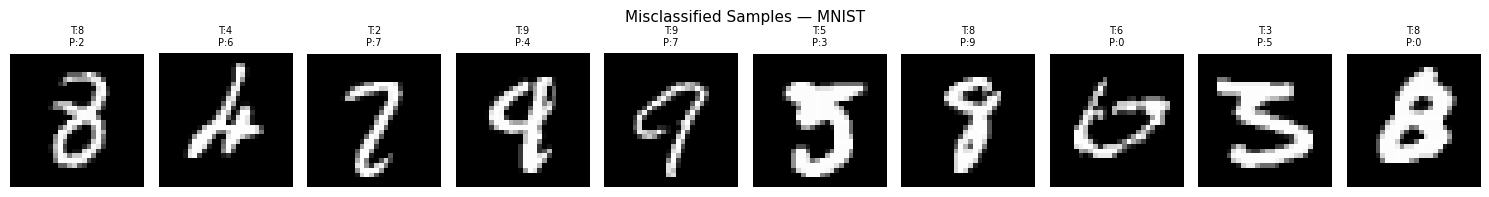

[LSTM-EMNIST-misclassified] Epoch 1/5 | Train Loss: 0.8431 Acc: 0.7480 | Val Loss: 0.4141 Acc: 0.8734
[LSTM-EMNIST-misclassified] Epoch 2/5 | Train Loss: 0.3349 Acc: 0.8928 | Val Loss: 0.3349 Acc: 0.8923
[LSTM-EMNIST-misclassified] Epoch 3/5 | Train Loss: 0.2691 Acc: 0.9119 | Val Loss: 0.2853 Acc: 0.9087
[LSTM-EMNIST-misclassified] Epoch 4/5 | Train Loss: 0.2342 Acc: 0.9218 | Val Loss: 0.2538 Acc: 0.9182
[LSTM-EMNIST-misclassified] Epoch 5/5 | Train Loss: 0.2130 Acc: 0.9274 | Val Loss: 0.2476 Acc: 0.9197


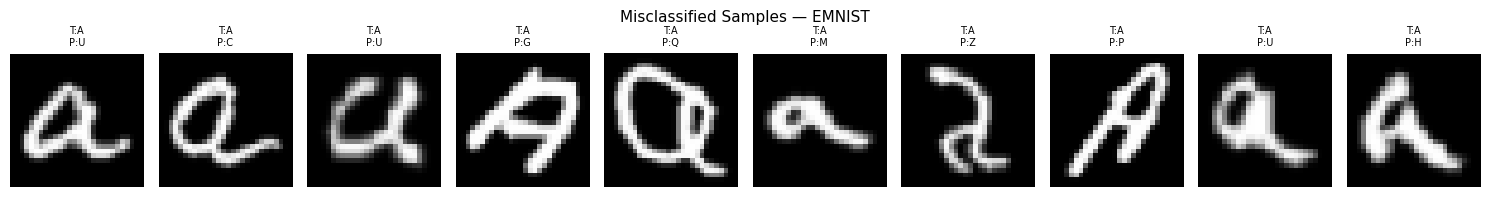

In [56]:
# Misclassified Samples Analysis
print("\n" + "=" * 60)
print("MISCLASSIFIED SAMPLES — LSTM MNIST & EMNIST")
print("=" * 60)

def plot_misclassified(model, loader, dataset_name, label_map, n=10):
    model.to(device)
    model.eval()
    wrong_imgs, wrong_true, wrong_pred = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs_d = imgs.to(device)
            outputs = model(imgs_d)
            preds   = outputs.argmax(1).cpu()
            mask    = preds != labels
            wrong_imgs.extend(imgs[mask])
            wrong_true.extend(labels[mask].numpy())
            wrong_pred.extend(preds[mask].numpy())
            if len(wrong_imgs) >= n:
                break

    fig, axes = plt.subplots(1, n, figsize=(15, 2))
    fig.suptitle(f"Misclassified Samples — {dataset_name}", fontsize=11)
    for i, ax in enumerate(axes):
        ax.imshow(wrong_imgs[i].squeeze(), cmap='gray')
        t = label_map[wrong_true[i]]
        p = label_map[wrong_pred[i]]
        ax.set_title(f"T:{t}\nP:{p}", fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# MNIST misclassified
mnist_label_map  = {i: str(i) for i in range(10)}
emnist_label_map = {i: chr(65+i) for i in range(26)}

plot_misclassified(tsne_model, mnist_test_loader,
                   'MNIST', mnist_label_map, n=10)

# EMNIST misclassified
emnist_best = LSTMModel(INPUT_SIZE, 128, 1, EMNIST_CLASSES, dropout=0.0)
opt_em      = optim.Adam(emnist_best.parameters(), lr=0.001)
train_model(emnist_best, emnist_train_loader, emnist_test_loader,
            opt_em, criterion, EPOCHS, "LSTM-EMNIST-misclassified")
plot_misclassified(emnist_best, emnist_test_loader,
                   'EMNIST', emnist_label_map, n=10)

In [57]:
# Final Summary Table
print("\n" + "=" * 60)
print("8.8 FINAL SUMMARY TABLE")
print("=" * 60)

print(f"\n{'Model':<20} {'MNIST Acc':>10} {'EMNIST Acc':>11} {'Params':>10} {'Inf(ms)':>9}")
print("-" * 63)

for i, (name, mnist_hist, emnist_hist) in enumerate(all_models):
    m_acc  = max(mnist_hist['val_acc'])
    e_acc  = max(emnist_hist['val_acc'])
    params = get_param_count(name, 'MNIST')
    inf_t  = inf_times[i]
    print(f"{name:<20} {m_acc:>10.4f} {e_acc:>11.4f} {params:>10,} {inf_t:>9.2f}")


8.8 FINAL SUMMARY TABLE

Model                 MNIST Acc  EMNIST Acc     Params   Inf(ms)
---------------------------------------------------------------
VanillaRNN               0.9604      0.8475     21,514      0.31
LSTM                     0.9818      0.9187     82,186      0.31
GRU                      0.9856      0.9243     61,962      0.56
BiLSTM                   0.9840      0.9273    164,362      0.40
BiGRU                    0.9882      0.9275    123,914      0.38
CNN+LSTM                 0.9912      0.9390    316,042      0.61
TimeCNN+LSTM             0.9846      0.9250    184,170      0.54
PureCNN                  0.9918      0.9405    824,458      0.52
